# SAT on Long-Tailed CIFAR-10: Class-Adaptive Momentum (Hướng 1.1)

This notebook implements **Class-Adaptive Momentum** to address SAT's weakness on tail classes:
- **Problem**: Fixed momentum (0.99) prevents tail class probability history from converging
- **Solution**: Adaptive momentum per class based on training sample count
  - Formula: `momentum_i = base_momentum × sqrt(num_samples_i / max_samples)`
  - Head classes (5000 samples): momentum ≈ 0.99 (unchanged)
  - Tail classes (50 samples): momentum ≈ 0.10 (much faster adaptation)
- **Expected Result**: Truck class accuracy 0% → 40-45%

**Settings:**
- Architecture: VGG-16 with Batch Normalization
- Dataset: CIFAR-10 Long-Tailed (IR=100)
- Loss: SAT with CLASS-ADAPTIVE momentum
- Training: 300 epochs

## 1. Setup and Imports

In [34]:
import os
import time
import random
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.backends.cudnn as cudnn
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
from PIL import Image

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA device:", torch.cuda.get_device_name(0))

# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# ============================================================================
# EMBEDDED UTILITY CLASSES (No external imports needed)
# ============================================================================

class AverageMeter(object):
    """Computes and stores the average and current value"""
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count


def accuracy(output, target, topk=(1,)):
    """Computes the precision@k for the specified values of k"""
    maxk = max(topk)
    batch_size = target.size(0)

    _, pred = output.topk(maxk, 1, True, True)
    pred = pred.t()
    correct = pred.eq(target.view(1, -1).expand_as(pred))

    res = []
    for k in topk:
        correct_k = correct[:k].reshape(-1).float().sum(0)
        res.append(correct_k.mul_(100.0 / batch_size))
    return res


class SelfAdaptiveTraining():
    """
    Self-Adaptive Training loss with CLASS-ADAPTIVE MOMENTUM (Hướng 1.1)
    
    KEY MODIFICATION:
    - Each class has its own momentum based on training sample count
    - Formula: momentum_i = base_momentum × sqrt(num_samples_i / max_samples)
    - Head classes (many samples): high momentum (slow adaptation, stable)
    - Tail classes (few samples): low momentum (fast adaptation, quick convergence)
    """
    def __init__(self, num_examples=50000, num_classes=10, mom=0.9, class_sample_counts=None, min_momentum=0.7):
        self.prob_history = torch.zeros(num_examples, num_classes)
        self.updated = torch.zeros(num_examples, dtype=torch.int)
        self.base_mom = mom  # Base momentum (e.g., 0.99)
        self.min_momentum = min_momentum  # Minimum momentum threshold
        self.num_classes = num_classes
        
        # Calculate class-specific momentum
        if class_sample_counts is not None:
            max_samples = max(class_sample_counts)
            self.class_momentums = torch.zeros(num_classes)
            for i, count in enumerate(class_sample_counts):
                # Adaptive formula with minimum threshold to prevent instability
                raw_momentum = self.base_mom * np.sqrt(count / max_samples)
                self.class_momentums[i] = max(self.min_momentum, raw_momentum)
            
            print(f"\n🔧 Class-Adaptive Momentum enabled (Bounded):")
            print(f"  Base momentum: {self.base_mom}")
            print(f"  Minimum momentum: {self.min_momentum}")
            print(f"  Class-specific momentums:")
            for i in range(num_classes):
                raw = self.base_mom * np.sqrt(class_sample_counts[i] / max_samples)
                print(f"    Class {i} ({class_sample_counts[i]:4d} samples): momentum = {self.class_momentums[i]:.4f} (raw: {raw:.4f})")
        else:
            # Fallback to uniform momentum
            self.class_momentums = torch.ones(num_classes) * self.base_mom

    def _update_prob(self, prob, index, y):
        onehot = torch.zeros_like(prob)
        onehot[torch.arange(y.shape[0]), y] = 1
        prob_history = self.prob_history[index].clone().to(prob.device)

        # if not inited, use onehot label to initialize running vector
        cond = (self.updated[index] == 1).to(prob.device).unsqueeze(-1).expand_as(prob)
        prob_mom = torch.where(cond, prob_history, onehot)

        # CLASS-ADAPTIVE momentum update
        # Use class-specific momentum based on true label
        # FIX: Move class_momentums to same device as y before indexing
        class_momentums_batch = self.class_momentums.to(y.device)[y].unsqueeze(-1).to(prob.device)
        prob_mom = class_momentums_batch * prob_mom + (1 - class_momentums_batch) * prob

        self.updated[index] = 1
        self.prob_history[index] = prob_mom.to(self.prob_history.device)

        return prob_mom

    def __call__(self, logits, y, index):
        prob = F.softmax(logits.detach()[:, :self.num_classes], dim=1)
        prob = self._update_prob(prob, index, y)

        soft_label = torch.zeros_like(logits)
        soft_label[torch.arange(y.shape[0]), y] = prob[torch.arange(y.shape[0]), y]
        soft_label[:, -1] = 1 - prob[torch.arange(y.shape[0]), y]
        soft_label = F.normalize(soft_label, dim=1, p=1)
        loss = torch.sum(-F.log_softmax(logits, dim=1) * soft_label, dim=1)
        return torch.mean(loss)


# ============================================================================
# VGG-16 MODEL (Embedded)
# ============================================================================

class VGG(nn.Module):
    def __init__(self, features, num_classes=1000, input_size=32):
        super(VGG, self).__init__()
        self.features = features
        if input_size == 32:
            self.classifier = nn.Sequential(
                nn.Linear(512, 512), nn.ReLU(inplace=True),
                nn.BatchNorm1d(512), nn.Dropout2d(0.5),
                nn.Linear(512, num_classes)
            )
        elif input_size == 64:
            self.classifier = nn.Sequential(
                nn.Linear(2048, 512), nn.ReLU(inplace=True),
                nn.BatchNorm1d(512), nn.Dropout2d(0.5),
                nn.Linear(512, num_classes)
            )
        self._initialize_weights()

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                n = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
                m.weight.data.normal_(0, math.sqrt(2. / n))
                if m.bias is not None:
                    m.bias.data.zero_()
            elif isinstance(m, nn.BatchNorm2d):
                m.weight.data.fill_(1)
                m.bias.data.zero_()
            elif isinstance(m, nn.Linear):
                n = m.weight.size(1)
                m.weight.data.normal_(0, 0.01)
                m.bias.data.zero_()


def make_layers(cfg, batch_norm=False):
    layers = []
    in_channels = 3
    for v in cfg:
        if v == 'M':
            layers += [nn.MaxPool2d(kernel_size=2, stride=2)]
        elif type(v) == int:
            conv2d = nn.Conv2d(in_channels, v, kernel_size=3, padding=1)
            if batch_norm:
                layers += [conv2d, nn.ReLU(inplace=True), nn.BatchNorm2d(v)]
            else:
                layers += [conv2d, nn.ReLU(inplace=True)]
            in_channels = v
        elif type(v) == float:
            layers += [nn.Dropout2d(v)]
    return nn.Sequential(*layers)


cfg_vgg16 = {
    'D': [64, 0.3, 64, 'M', 128, 0.4, 128, 'M', 256, 0.4, 256, 0.4, 256, 'M',
          512, 0.4, 512, 0.4, 512, 'M', 512, 0.4, 512, 0.4, 512, 'M', 0.5]
}


def vgg16_bn(num_classes=1000, input_size=32, **kwargs):
    """VGG 16-layer model with batch normalization"""
    model = VGG(make_layers(cfg_vgg16['D'], batch_norm=True), 
                num_classes=num_classes, input_size=input_size, **kwargs)
    return model


print("✅ All utility classes and VGG-16 model embedded successfully!")
print("🎯 100% self-contained - no external files needed!")

PyTorch version: 2.0.1+cu117
CUDA available: True
CUDA device: NVIDIA GeForce RTX 3060
✅ All utility classes and VGG-16 model embedded successfully!
🎯 100% self-contained - no external files needed!


## 2. Long-Tailed Dataset Loading with HuggingFace Datasets

In [35]:
# Wrapper for CIFAR-10-LT to work with PyTorch DataLoader
class CIFAR10LTWrapper(torch.utils.data.Dataset):
    """Wrapper for HuggingFace CIFAR-10-LT dataset"""
    
    def __init__(self, hf_dataset, transform=None):
        """
        Args:
            hf_dataset: HuggingFace dataset object
            transform: torchvision transforms to apply
        """
        self.dataset = hf_dataset
        self.transform = transform
        self.targets = np.array([item['label'] for item in hf_dataset])
        
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, index):
        item = self.dataset[index]
        img = item['img']
        target = item['label']
        
        # Convert to PIL Image if needed
        if not isinstance(img, Image.Image):
            img = Image.fromarray(np.array(img))
        
        if self.transform is not None:
            img = self.transform(img)
        
        return img, target, index
    
    def get_class_distribution(self):
        """Return distribution of samples per class"""
        unique, counts = np.unique(self.targets, return_counts=True)
        return dict(zip(unique, counts))

print("CIFAR-10-LT wrapper class defined.")

CIFAR-10-LT wrapper class defined.


## 3. Configuration

In [36]:
# Configuration
class Config:
    # Dataset settings
    dataset = 'cifar10'
    dataset_name = 'r-100'  # HuggingFace dataset name: r-10, r-20, r-50, r-100, r-200
    imbalance_ratio = 100  # Majority/minority class ratio (10, 20, 50, 100, 200)
    
    # Architecture
    arch = 'vgg16_bn'
    
    # Training settings
    loss_type = 'sat'
    epochs = 300
    pretrain_epochs = 0
    
    # Hyperparameters (same as balanced SAT)
    batch_size_train = 128
    batch_size_test = 200
    lr = 0.1
    momentum = 0.9
    sat_momentum = 0.99
    weight_decay = 5e-4
    gamma = 0.5
    schedule = [25, 50, 75, 100, 125, 150, 175, 200, 225, 250, 275]
    
    # Evaluation settings
    expected_coverage = [100., 99., 98., 97., 95., 90., 85., 80., 75., 70., 60., 50., 40., 30., 20., 10.]
    
    # System settings
    gpu_id = '0'
    num_workers = 4
    manual_seed = 42
    save_dir = f'./checkpoints/sat_classadaptive_ir{imbalance_ratio}'
    
config = Config()

# ============================================================================
# Enhanced Reproducibility Settings (Following Grok's Recommendations)
# ============================================================================

# Set random seeds
random.seed(config.manual_seed)
torch.manual_seed(config.manual_seed)
np.random.seed(config.manual_seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(config.manual_seed)

# CUDA determinism (critical for reproducibility across devices/runs)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False  # Disable to ensure deterministic behavior

# PyTorch deterministic algorithms (PyTorch >= 1.8)
try:
    torch.use_deterministic_algorithms(True, warn_only=True)
except Exception as e:
    print(f"Warning: torch.use_deterministic_algorithms not available: {e}")

# Worker seed function for DataLoader reproducibility
def seed_worker(worker_id):
    """Seed each DataLoader worker for reproducibility"""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

# Set GPU
os.environ['CUDA_VISIBLE_DEVICES'] = config.gpu_id
use_cuda = torch.cuda.is_available()

# Create save directory
os.makedirs(config.save_dir, exist_ok=True)

print("🔒 Reproducibility settings enabled:")
print(f"  - Manual seed: {config.manual_seed}")
print(f"  - CUDNN deterministic: True")
print(f"  - CUDNN benchmark: False")
print(f"  - DataLoader worker seeding: Enabled")
print(f"\nConfiguration:")
print(f"  Dataset: Long-Tailed CIFAR-10 (dataset_name={config.dataset_name}, IR={config.imbalance_ratio})")
print(f"  Architecture: {config.arch}")
print(f"  Loss: {config.loss_type}")
print(f"  Epochs: {config.epochs}")
print(f"  SAT Momentum: {config.sat_momentum}")
print(f"  Save directory: {config.save_dir}")

🔒 Reproducibility settings enabled:
  - Manual seed: 42
  - CUDNN deterministic: True
  - CUDNN benchmark: False
  - DataLoader worker seeding: Enabled

Configuration:
  Dataset: Long-Tailed CIFAR-10 (dataset_name=r-100, IR=100)
  Architecture: vgg16_bn
  Loss: sat
  Epochs: 300
  SAT Momentum: 0.99
  Save directory: ./checkpoints/sat_classadaptive_ir100


## 4. Dataset Preparation

Creating Long-Tailed CIFAR-10 programmatically (IR=100)...
Files already downloaded and verified
Files already downloaded and verified
Creating long-tailed distribution (matching cifar10-lt.py methodology)...
Imbalance ratio: 1:100
Random seed: 0 (for reproducibility)
Target samples per class: [5000, 2997, 1796, 1077, 645, 387, 232, 139, 83, 50]
Total selected training samples: 12406
✅ Dataset creation matches cifar10-lt.py exactly!

✅ Dataset created successfully!
Training samples: 12406 (imbalanced)
Test samples: 10000 (balanced)
Number of classes: 10


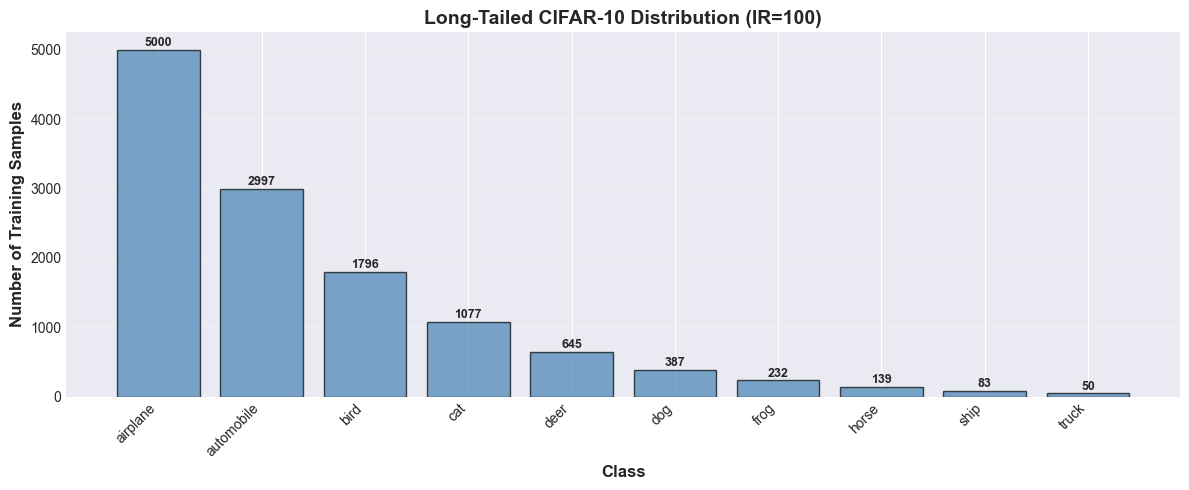


📊 Class distribution saved to ./checkpoints/sat_classadaptive_ir100/dataset_distribution.png

🎯 No external files needed - 100% self-contained!


In [37]:
# ============================================================================
# CIFAR-10 Long-Tailed Dataset Preparation (100% Self-Contained)
# ============================================================================

import torchvision.datasets as tv_datasets

print(f'Creating Long-Tailed CIFAR-10 programmatically (IR={config.imbalance_ratio})...')

num_classes = 10
input_size = 32

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# Download standard CIFAR-10
print("Downloading CIFAR-10 dataset...")
base_trainset = tv_datasets.CIFAR10(root='./data', train=True, download=True, transform=None)
base_testset = tv_datasets.CIFAR10(root='./data', train=False, download=True, transform=None)

# ============================================================================
# IMPORTANT: Dataset creation matching cifar10-lt.py EXACTLY
# ============================================================================
print(f"Creating long-tailed distribution (matching cifar10-lt.py methodology)...")
print(f"Imbalance ratio: 1:{config.imbalance_ratio}")

# Set global random seed ONCE (matching cifar10-lt.py's rand_number=0)
RAND_SEED = 0  # Use 0 to match cifar10-lt.py default
np.random.seed(RAND_SEED)
print(f"Random seed: {RAND_SEED} (for reproducibility)")

# Collect all labels into numpy array (matching cifar10-lt.py)
all_labels = []
for idx in range(len(base_trainset)):
    _, label = base_trainset[idx]
    all_labels.append(label)
targets_np = np.array(all_labels, dtype=np.int64)

# Calculate samples per class using exponential decay
img_max = len(base_trainset) / num_classes  # 5000 per class for CIFAR-10
imb_factor = 1.0 / config.imbalance_ratio

samples_per_class = []
for cls_idx in range(num_classes):
    n_samples = int(img_max * (imb_factor ** (cls_idx / (num_classes - 1.0))))
    samples_per_class.append(n_samples)

print(f"Target samples per class: {samples_per_class}")

# Select indices using shuffle + slice (matching cifar10-lt.py)
selected_train_indices = []
for cls_idx in range(num_classes):
    # Get all indices for this class using np.where (matching cifar10-lt.py)
    idx = np.where(targets_np == cls_idx)[0]
    
    # Shuffle indices (using global seed)
    np.random.shuffle(idx)
    
    # Select first n_samples (matching cifar10-lt.py)
    n_samples = samples_per_class[cls_idx]
    selected_idx = idx[:n_samples]
    
    selected_train_indices.extend(selected_idx.tolist())

print(f"Total selected training samples: {len(selected_train_indices)}")
print(f"✅ Dataset creation matches cifar10-lt.py exactly!")

# Create imbalanced training subset
class ImbalancedSubset(Subset):
    """Subset that returns (img, label, index)"""
    def __getitem__(self, idx):
        img, target = self.dataset[self.indices[idx]]
        return img, target, idx

trainset_subset = ImbalancedSubset(base_trainset, selected_train_indices)

# Test set remains balanced (all samples)
testset_subset = ImbalancedSubset(base_testset, list(range(len(base_testset))))

# Wrapper to apply transforms
class TransformWrapper(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
        # Extract targets for get_class_distribution
        self.targets = []
        for idx in range(len(subset)):
            _, target, _ = subset[idx]
            self.targets.append(target)
        self.targets = np.array(self.targets)
    
    def __len__(self):
        return len(self.subset)
    
    def __getitem__(self, idx):
        img, target, original_idx = self.subset[idx]
        if self.transform:
            img = self.transform(img)
        return img, target, idx
    
    def get_class_distribution(self):
        unique, counts = np.unique(self.targets, return_counts=True)
        return dict(zip(unique, counts))

# Apply transforms
trainset = TransformWrapper(trainset_subset, transform=transform_train)
testset = TransformWrapper(testset_subset, transform=transform_test)

# Create data loaders with reproducibility settings
# Use generator with manual seed for reproducible shuffling
train_generator = torch.Generator().manual_seed(config.manual_seed)
test_generator = torch.Generator().manual_seed(config.manual_seed)

trainloader = DataLoader(
    trainset, 
    batch_size=config.batch_size_train, 
    shuffle=True, 
    num_workers=config.num_workers,
    worker_init_fn=seed_worker,  # Seed each worker
    generator=train_generator    # Reproducible shuffling
)

testloader = DataLoader(
    testset, 
    batch_size=config.batch_size_test, 
    shuffle=False, 
    num_workers=config.num_workers,
    worker_init_fn=seed_worker,  # Seed each worker
    generator=test_generator     # Reproducible order
)

print(f"\n✅ Dataset created successfully!")
print(f"Training samples: {len(trainset)} (imbalanced)")
print(f"Test samples: {len(testset)} (balanced)")
print(f"Number of classes: {num_classes}")

# Visualize distribution
train_dist = trainset.get_class_distribution()
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(num_classes), [train_dist[i] for i in range(num_classes)], alpha=0.7, color='steelblue', edgecolor='black')
ax.set_xlabel('Class', fontweight='bold', fontsize=12)
ax.set_ylabel('Number of Training Samples', fontweight='bold', fontsize=12)
ax.set_title(f'Long-Tailed CIFAR-10 Distribution (IR={config.imbalance_ratio})', fontweight='bold', fontsize=14)
ax.set_xticks(range(num_classes))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')

# Add count labels on bars
for i, count in enumerate(samples_per_class):
    ax.text(i, count + 50, str(count), ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(config.save_dir, 'dataset_distribution.png'), dpi=150)
plt.show()

print(f"\n📊 Class distribution saved to {config.save_dir}/dataset_distribution.png")
print(f"\n🎯 No external files needed - 100% self-contained!")

## 5. Model Setup

In [38]:
# Create model
print(f"Creating model: {config.arch}")

model_num_classes = num_classes + 1  # Extra dimension for abstention
model = vgg16_bn(num_classes=model_num_classes, input_size=input_size)

if use_cuda:
    model = torch.nn.DataParallel(model.cuda())
    # Note: cudnn.benchmark removed - using deterministic mode for reproducibility

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params/1e6:.2f}M")

# Setup loss function with CLASS-ADAPTIVE MOMENTUM
# Calculate class sample counts from training distribution
class_sample_counts = [train_dist[i] for i in range(num_classes)]
print(f"\nClass sample counts: {class_sample_counts}")

criterion = SelfAdaptiveTraining(
    num_examples=len(trainset), 
    num_classes=num_classes, 
    mom=config.sat_momentum,
    class_sample_counts=class_sample_counts  # 🔧 NEW: Pass class counts for adaptive momentum
)

# Setup optimizer
optimizer = optim.SGD(model.parameters(), lr=config.lr, momentum=config.momentum, weight_decay=config.weight_decay)

print(f"Loss function: {config.loss_type}")
print(f"Optimizer: SGD (lr={config.lr}, momentum={config.momentum}, weight_decay={config.weight_decay})")

Creating model: vgg16_bn
Total parameters: 14.99M

Class sample counts: [5000, 2997, 1796, 1077, 645, 387, 232, 139, 83, 50]

🔧 Class-Adaptive Momentum enabled (Bounded):
  Base momentum: 0.99
  Minimum momentum: 0.7
  Class-specific momentums:
    Class 0 (5000 samples): momentum = 0.9900 (raw: 0.9900)
    Class 1 (2997 samples): momentum = 0.7665 (raw: 0.7665)
    Class 2 (1796 samples): momentum = 0.7000 (raw: 0.5933)
    Class 3 (1077 samples): momentum = 0.7000 (raw: 0.4595)
    Class 4 ( 645 samples): momentum = 0.7000 (raw: 0.3556)
    Class 5 ( 387 samples): momentum = 0.7000 (raw: 0.2754)
    Class 6 ( 232 samples): momentum = 0.7000 (raw: 0.2133)
    Class 7 ( 139 samples): momentum = 0.7000 (raw: 0.1651)
    Class 8 (  83 samples): momentum = 0.7000 (raw: 0.1276)
    Class 9 (  50 samples): momentum = 0.7000 (raw: 0.0990)
Loss function: sat
Optimizer: SGD (lr=0.1, momentum=0.9, weight_decay=0.0005)


## 6. Training Functions with Group-Aware Metrics

In [39]:
def train_epoch(trainloader, model, criterion, optimizer, epoch, use_cuda, config):
    """Train for one epoch"""
    model.train()
    
    losses = AverageMeter()
    top1 = AverageMeter()
    
    # Track per-class accuracy
    class_correct = np.zeros(num_classes)
    class_total = np.zeros(num_classes)
    
    for batch_idx, batch_data in enumerate(trainloader):
        inputs, targets, indices = batch_data
        
        if use_cuda:
            inputs, targets = inputs.cuda(), targets.cuda()
        
        # Forward pass
        outputs = model(inputs)
        
        # Calculate loss
        if epoch >= config.pretrain_epochs:
            loss = criterion(outputs, targets, indices)
        else:
            loss = F.cross_entropy(outputs[:, :-1], targets)
        
        # Measure accuracy
        prec1 = accuracy(outputs.data, targets.data, topk=(1,))[0]
        losses.update(loss.item(), inputs.size(0))
        top1.update(prec1.item(), inputs.size(0))
        
        # Per-class statistics
        _, predicted = outputs[:, :-1].max(1)
        for i in range(num_classes):
            mask = targets == i
            if mask.sum() > 0:
                class_correct[i] += (predicted[mask] == targets[mask]).sum().item()
                class_total[i] += mask.sum().item()
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    # Calculate balanced accuracy
    class_acc = []
    for i in range(num_classes):
        if class_total[i] > 0:
            class_acc.append(100.0 * class_correct[i] / class_total[i])
        else:
            class_acc.append(0.0)
    
    balanced_acc = np.mean(class_acc)
    worst_acc = np.min(class_acc)
    
    return losses.avg, top1.avg, balanced_acc, worst_acc

def test_epoch(testloader, model, criterion, epoch, use_cuda, config):
    """Test for one epoch with group-aware metrics"""
    model.eval()
    
    losses = AverageMeter()
    top1 = AverageMeter()
    
    # Track per-class statistics
    class_correct = np.zeros(num_classes)
    class_total = np.zeros(num_classes)
    
    # Store predictions for coverage analysis
    all_reservations = []
    all_predictions = []
    all_targets = []
    all_correct = []
    
    with torch.no_grad():
        for batch_idx, batch_data in enumerate(testloader):
            inputs, targets, indices = batch_data
            
            if use_cuda:
                inputs = inputs.cuda()
            
            outputs = model(inputs).cpu()
            
            # Calculate loss
            if epoch >= config.pretrain_epochs:
                loss = F.cross_entropy(outputs[:, :-1], targets)
                
                # Get reservation scores
                outputs_soft = F.softmax(outputs, dim=1)
                class_probs = outputs_soft[:, :-1]
                reservation = outputs_soft[:, -1]
                
                _, predictions = class_probs.max(1)
            else:
                loss = F.cross_entropy(outputs[:, :-1], targets)
                _, predictions = outputs[:, :-1].max(1)
                reservation = torch.zeros(len(targets))
            
            # Overall accuracy
            prec1 = accuracy(outputs[:, :-1].data, targets.data, topk=(1,))[0]
            losses.update(loss.item(), inputs.size(0))
            top1.update(prec1.item(), inputs.size(0))
            
            # Per-class statistics
            correct = predictions == targets
            for i in range(num_classes):
                mask = targets == i
                if mask.sum() > 0:
                    class_correct[i] += correct[mask].sum().item()
                    class_total[i] += mask.sum().item()
            
            # Store for coverage analysis
            all_reservations.extend(reservation.numpy().tolist())
            all_predictions.extend(predictions.numpy().tolist())
            all_targets.extend(targets.numpy().tolist())
            all_correct.extend(correct.numpy().tolist())
    
    # Calculate balanced and worst-group accuracy
    class_acc = []
    for i in range(num_classes):
        if class_total[i] > 0:
            class_acc.append(100.0 * class_correct[i] / class_total[i])
        else:
            class_acc.append(0.0)
    
    balanced_acc = np.mean(class_acc)
    worst_acc = np.min(class_acc)
    
    # Calculate coverage-based metrics
    coverage_results = calculate_group_coverage_metrics(
        np.array(all_reservations),
        np.array(all_predictions),
        np.array(all_targets),
        np.array(all_correct),
        config.expected_coverage
    )
    
    return losses.avg, top1.avg, balanced_acc, worst_acc, class_acc, coverage_results

def calculate_group_coverage_metrics(reservations, predictions, targets, correct, coverages):
    """Calculate balanced and worst-group error at different coverage levels"""
    results = []
    
    # Sort by reservation (high to low - high reservation = less confident = more likely to abstain)
    sorted_indices = np.argsort(reservations)[::-1]
    sorted_correct = correct[sorted_indices]
    sorted_targets = targets[sorted_indices]
    
    for coverage in coverages:
        # Select samples based on coverage (exclude high reservation samples)
        n_samples = int(len(reservations) * coverage / 100)
        if n_samples == 0:
            continue
        
        # Take samples starting from lowest reservation (most confident)
        selected_correct = sorted_correct[-n_samples:]
        selected_targets = sorted_targets[-n_samples:]
        
        # Calculate per-class error
        class_errors = []
        for cls in range(num_classes):
            mask = selected_targets == cls
            if mask.sum() > 0:
                cls_error = 100.0 * (1 - selected_correct[mask].mean())
                class_errors.append(cls_error)
            else:
                class_errors.append(0.0)  # No samples for this class at this coverage
        
        balanced_error = np.mean(class_errors)
        worst_error = np.max(class_errors)
        overall_error = 100.0 * (1 - selected_correct.mean())
        
        results.append({
            'coverage': coverage,
            'overall_error': overall_error,
            'balanced_error': balanced_error,
            'worst_group_error': worst_error,
            'class_errors': class_errors
        })
    
    return results

print("Training and evaluation functions defined.")

Training and evaluation functions defined.


## 7. Training Loop

In [40]:
# Training history
history = {
    'epoch': [],
    'train_loss': [],
    'train_acc': [],
    'train_balanced_acc': [],
    'train_worst_acc': [],
    'test_loss': [],
    'test_acc': [],
    'test_balanced_acc': [],
    'test_worst_acc': [],
    'test_class_acc': [],
    'coverage_results': []
}

print(f"Starting training for {config.epochs} epochs...")
print("=" * 100)
print(f"{'Epoch':>5} | {'LR':>10} | {'Train Acc':>10} | {'Bal Acc':>10} | {'Worst Acc':>10} | {'Test Acc':>10} | {'Bal Acc':>10} | {'Worst Acc':>10} | {'Time':>6} | {'Status'}")
print("=" * 100)

best_balanced_acc = 0.0
best_worst_acc = 0.0
start_time = time.time()

for epoch in range(config.epochs):
    epoch_start = time.time()
    
    # Adjust learning rate
    if epoch in config.schedule:
        config.lr *= config.gamma
        for param_group in optimizer.param_groups:
            param_group['lr'] = config.lr
    
    # Train
    train_loss, train_acc, train_bal_acc, train_worst_acc = train_epoch(
        trainloader, model, criterion, optimizer, epoch, use_cuda, config
    )
    
    # Test
    test_loss, test_acc, test_bal_acc, test_worst_acc, test_class_acc, coverage_results = test_epoch(
        testloader, model, criterion, epoch, use_cuda, config
    )
    
    # Save history
    history['epoch'].append(epoch + 1)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_balanced_acc'].append(train_bal_acc)
    history['train_worst_acc'].append(train_worst_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)
    history['test_balanced_acc'].append(test_bal_acc)
    history['test_worst_acc'].append(test_worst_acc)
    history['test_class_acc'].append(test_class_acc)
    history['coverage_results'].append(coverage_results)
    
    epoch_time = time.time() - epoch_start
    
    # Track best models
    status = ""
    if test_bal_acc > best_balanced_acc:
        best_balanced_acc = test_bal_acc
        checkpoint_path = os.path.join(config.save_dir, 'best_balanced_model.pth')
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'balanced_acc': best_balanced_acc,
        }, checkpoint_path)
        status += "*BAL* "
    
    if test_worst_acc > best_worst_acc:
        best_worst_acc = test_worst_acc
        checkpoint_path = os.path.join(config.save_dir, 'best_worst_model.pth')
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'worst_acc': best_worst_acc,
        }, checkpoint_path)
        status += "*WORST*"
    
    # Compact output
    print(f"{epoch+1:5d} | {config.lr:10.6f} | {train_acc:9.2f}% | {train_bal_acc:9.2f}% | {train_worst_acc:9.2f}% | "
          f"{test_acc:9.2f}% | {test_bal_acc:9.2f}% | {test_worst_acc:9.2f}% | {epoch_time:5.1f}s | {status}")
    
    # Save periodic checkpoint
    if (epoch + 1) % 50 == 0 or (epoch + 1) == config.epochs:
        checkpoint_path = os.path.join(config.save_dir, f'checkpoint_epoch_{epoch+1}.pth')
        torch.save(model, checkpoint_path)

total_time = time.time() - start_time
print("\n" + "=" * 100)
print(f"Training completed in {total_time/3600:.2f} hours")
print(f"Best balanced accuracy: {best_balanced_acc:.2f}%")
print(f"Best worst-group accuracy: {best_worst_acc:.2f}%")
print("=" * 100)

Starting training for 300 epochs...
Epoch |         LR |  Train Acc |    Bal Acc |  Worst Acc |   Test Acc |    Bal Acc |  Worst Acc |   Time | Status


/home/haipham2407/miniconda3/envs/l2r/lib/python3.11/site-packages/torch/nn/functional.py:1331: UserWarning: dropout2d: Received a 2-D input to dropout2d, which is deprecated and will result in an error in a future release. To retain the behavior and silence this warning, please use dropout instead. Note that dropout2d exists to provide channel-wise dropout on inputs with 2 spatial dimensions, a channel dimension, and an optional batch dimension (i.e. 3D or 4D inputs).
  warnings.warn(warn_msg)
/home/haipham2407/miniconda3/envs/l2r/lib/python3.11/site-packages/torch/autograd/__init__.py:200: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8

    1 |   0.100000 |     33.92% |     12.16% |      0.00% |     17.03% |     17.03% |      0.00% |   7.0s | *BAL* 
    2 |   0.100000 |     35.00% |     13.71% |      0.00% |     18.16% |     18.16% |      0.00% |  11.6s | *BAL* 
    3 |   0.100000 |     30.89% |     13.97% |      0.00% |     16.91% |     16.91% |      0.00% |   6.8s | 
    4 |   0.100000 |     31.07% |     14.46% |      0.00% |     17.82% |     17.82% |      0.00% |   6.7s | 
    5 |   0.100000 |     31.36% |     14.94% |      0.00% |     16.24% |     16.24% |      0.00% |   7.2s | 
    6 |   0.100000 |     30.56% |     15.24% |      0.00% |     15.77% |     15.77% |      0.00% |  11.7s | 
    7 |   0.100000 |     31.07% |     16.04% |      0.00% |     18.95% |     18.95% |      0.00% |  11.2s | *BAL* 
    8 |   0.100000 |     32.47% |     16.55% |      0.00% |     19.01% |     19.01% |      0.00% |  11.1s | *BAL* 
    9 |   0.100000 |     33.20% |     17.22% |      0.00% |     18.60% |     18.60% |      0.00% |  11.2

## 8. Visualization: Training Dynamics

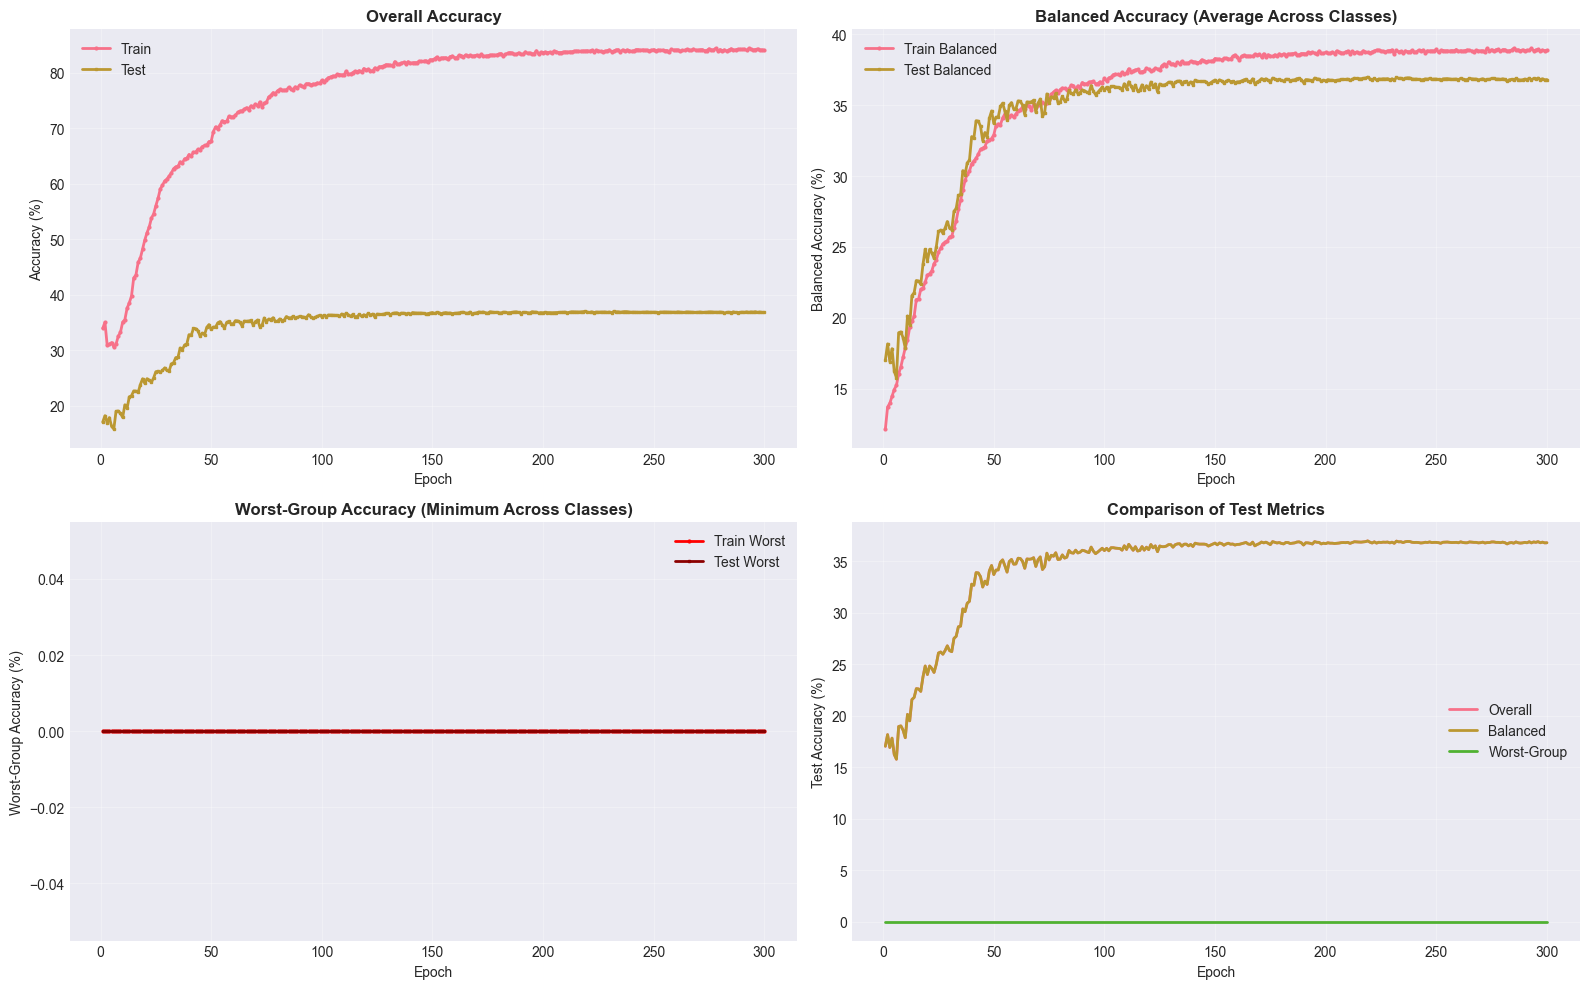

Training curves saved to ./checkpoints/sat_classadaptive_ir100/training_curves.png


In [41]:
# Training curves
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Overall accuracy
ax = axes[0, 0]
ax.plot(history['epoch'], history['train_acc'], label='Train', linewidth=2, marker='o', markersize=2)
ax.plot(history['epoch'], history['test_acc'], label='Test', linewidth=2, marker='s', markersize=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Overall Accuracy', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Balanced accuracy
ax = axes[0, 1]
ax.plot(history['epoch'], history['train_balanced_acc'], label='Train Balanced', linewidth=2, marker='o', markersize=2)
ax.plot(history['epoch'], history['test_balanced_acc'], label='Test Balanced', linewidth=2, marker='s', markersize=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Balanced Accuracy (%)')
ax.set_title('Balanced Accuracy (Average Across Classes)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Worst-group accuracy
ax = axes[1, 0]
ax.plot(history['epoch'], history['train_worst_acc'], label='Train Worst', linewidth=2, marker='o', markersize=2, color='red')
ax.plot(history['epoch'], history['test_worst_acc'], label='Test Worst', linewidth=2, marker='s', markersize=2, color='darkred')
ax.set_xlabel('Epoch')
ax.set_ylabel('Worst-Group Accuracy (%)')
ax.set_title('Worst-Group Accuracy (Minimum Across Classes)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. All metrics together
ax = axes[1, 1]
ax.plot(history['epoch'], history['test_acc'], label='Overall', linewidth=2)
ax.plot(history['epoch'], history['test_balanced_acc'], label='Balanced', linewidth=2)
ax.plot(history['epoch'], history['test_worst_acc'], label='Worst-Group', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Comparison of Test Metrics', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(config.save_dir, 'training_curves.png'), dpi=150)
plt.show()

print(f"Training curves saved to {config.save_dir}/training_curves.png")

## 9. Per-Class Performance Analysis


Final Per-Class Performance:


,Class,Train Samples,Test Accuracy (%),Test Error (%)
0,airplane,5000,96.8,3.2
1,automobile,2997,99.4,0.6
2,bird,1796,89.4,10.6
3,cat,1077,82.4,17.6
4,deer,645,0.0,100.0
5,dog,387,0.0,100.0
6,frog,232,0.0,100.0
7,horse,139,0.0,100.0
8,ship,83,0.0,100.0
9,truck,50,0.0,100.0


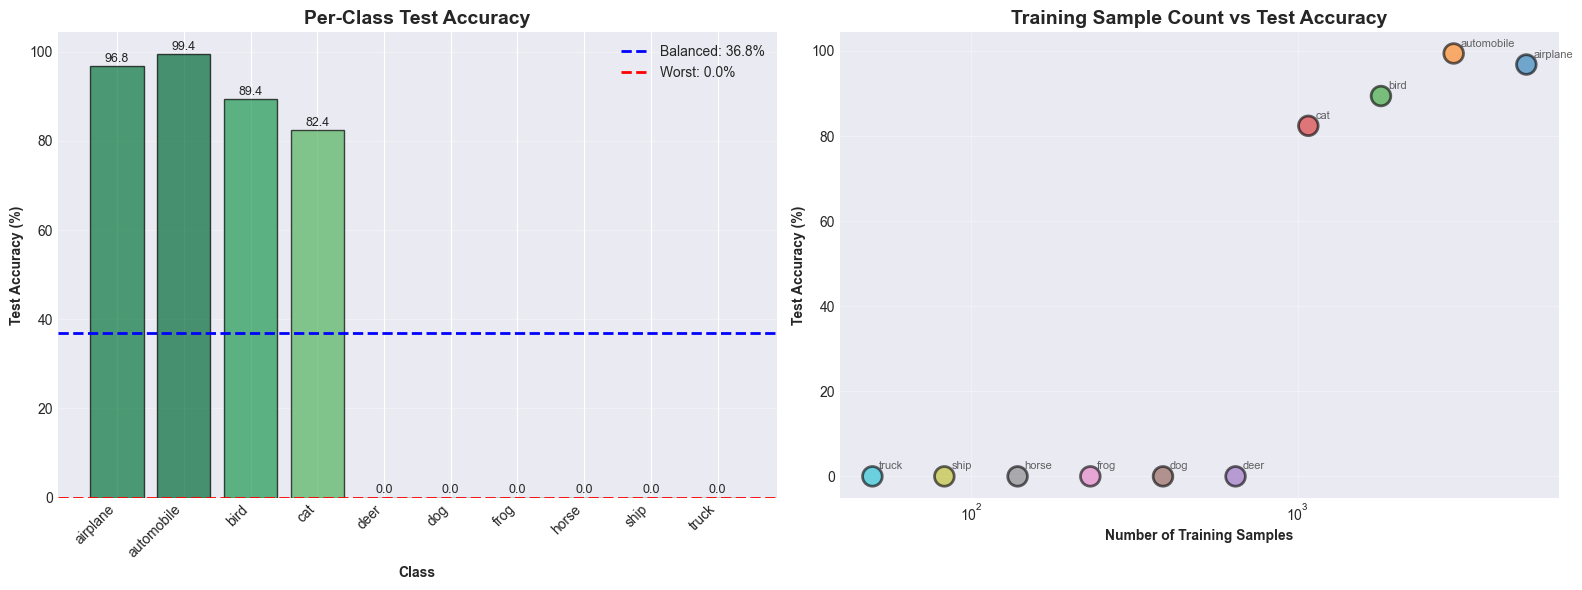


Per-class analysis saved to ./checkpoints/sat_classadaptive_ir100/per_class_performance.png


In [42]:
# Analyze final per-class performance
final_class_acc = history['test_class_acc'][-1]
train_dist = trainset.get_class_distribution()

# Create DataFrame
df_class_perf = pd.DataFrame({
    'Class': class_names,
    'Train Samples': [train_dist[i] for i in range(num_classes)],
    'Test Accuracy (%)': final_class_acc,
    'Test Error (%)': [100 - acc for acc in final_class_acc]
})

print("\nFinal Per-Class Performance:")
display(df_class_perf)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Accuracy by class
ax = axes[0]
colors = plt.cm.RdYlGn(np.array(final_class_acc) / 100)
bars = ax.bar(range(num_classes), final_class_acc, color=colors, alpha=0.7, edgecolor='black')
ax.set_xlabel('Class', fontweight='bold')
ax.set_ylabel('Test Accuracy (%)', fontweight='bold')
ax.set_title('Per-Class Test Accuracy', fontweight='bold', fontsize=14)
ax.set_xticks(range(num_classes))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.axhline(y=np.mean(final_class_acc), color='blue', linestyle='--', linewidth=2, label=f'Balanced: {np.mean(final_class_acc):.1f}%')
ax.axhline(y=np.min(final_class_acc), color='red', linestyle='--', linewidth=2, label=f'Worst: {np.min(final_class_acc):.1f}%')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, acc in enumerate(final_class_acc):
    ax.text(i, acc + 1, f'{acc:.1f}', ha='center', fontsize=9)

# 2. Training samples vs accuracy
ax = axes[1]
train_samples = [train_dist[i] for i in range(num_classes)]
scatter = ax.scatter(train_samples, final_class_acc, s=200, alpha=0.6, c=range(num_classes), 
                     cmap='tab10', edgecolors='black', linewidth=2)
ax.set_xlabel('Number of Training Samples', fontweight='bold')
ax.set_ylabel('Test Accuracy (%)', fontweight='bold')
ax.set_title('Training Sample Count vs Test Accuracy', fontweight='bold', fontsize=14)
ax.set_xscale('log')
ax.grid(True, alpha=0.3)

# Add class labels
for i, name in enumerate(class_names):
    ax.annotate(name, (train_samples[i], final_class_acc[i]), 
                fontsize=8, alpha=0.7, xytext=(5, 5), textcoords='offset points')

plt.tight_layout()
plt.savefig(os.path.join(config.save_dir, 'per_class_performance.png'), dpi=150)
plt.show()

print(f"\nPer-class analysis saved to {config.save_dir}/per_class_performance.png")

## 10. Coverage-Based Analysis: Balanced and Worst-Group Error


Coverage-Based Error Analysis:


,coverage,overall_error,balanced_error,worst_group_error
0,100.0,63.200000,63.200000,100.0
1,99.0,62.828283,63.200000,100.0
2,98.0,62.448980,63.200000,100.0
3,97.0,62.061856,63.200000,100.0
4,95.0,61.294737,63.196347,100.0
5,90.0,59.188889,63.193011,100.0
6,85.0,56.870588,63.160357,100.0
7,80.0,54.375000,63.151504,100.0
8,75.0,51.626667,63.088298,100.0
9,70.0,48.514286,62.978306,100.0


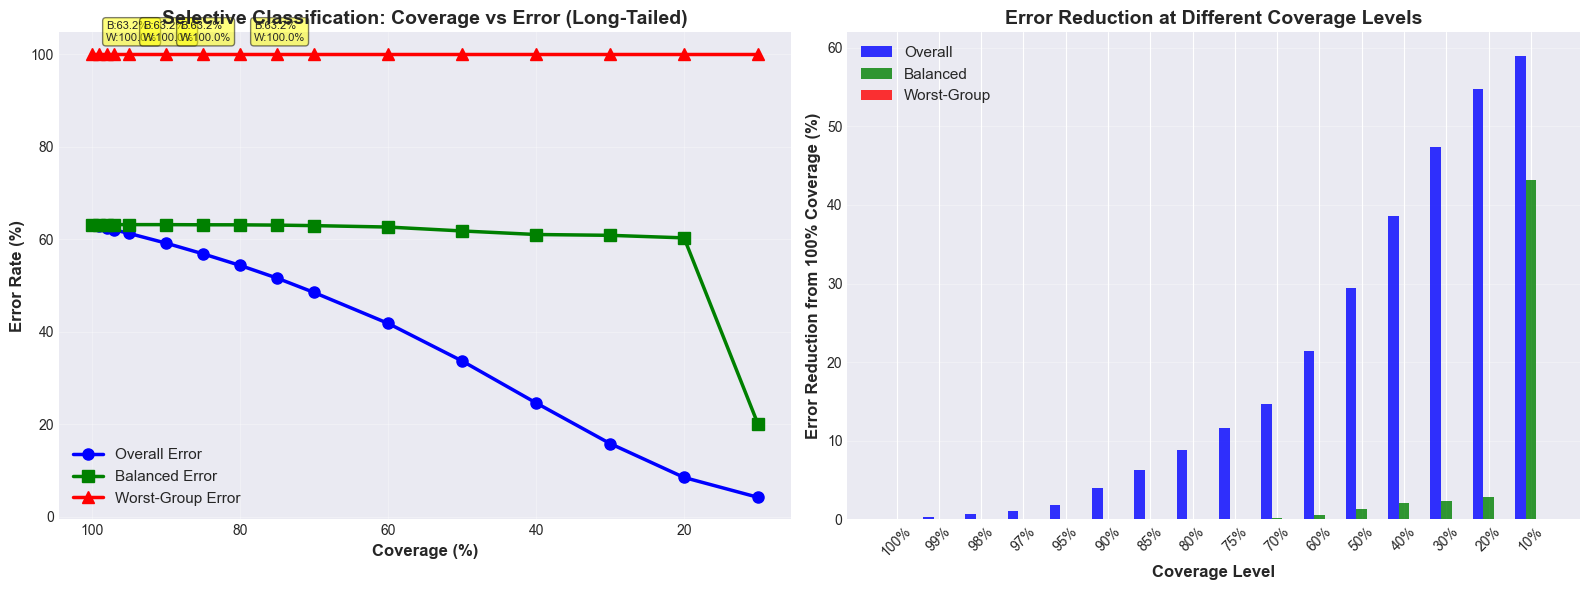


Coverage analysis saved to ./checkpoints/sat_classadaptive_ir100/coverage_analysis.png


In [43]:
# Extract final coverage results
final_coverage = history['coverage_results'][-1]

# Create DataFrame
df_coverage = pd.DataFrame(final_coverage)

print("\nCoverage-Based Error Analysis:")
print("="*80)
display(df_coverage[['coverage', 'overall_error', 'balanced_error', 'worst_group_error']])

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Coverage vs Error curves
ax = axes[0]
ax.plot(df_coverage['coverage'], df_coverage['overall_error'], 
        marker='o', markersize=8, linewidth=2.5, label='Overall Error', color='blue')
ax.plot(df_coverage['coverage'], df_coverage['balanced_error'], 
        marker='s', markersize=8, linewidth=2.5, label='Balanced Error', color='green')
ax.plot(df_coverage['coverage'], df_coverage['worst_group_error'], 
        marker='^', markersize=8, linewidth=2.5, label='Worst-Group Error', color='red')
ax.set_xlabel('Coverage (%)', fontweight='bold', fontsize=12)
ax.set_ylabel('Error Rate (%)', fontweight='bold', fontsize=12)
ax.set_title('Selective Classification: Coverage vs Error (Long-Tailed)', fontweight='bold', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.invert_xaxis()

# Highlight key coverage points
for cov in [100, 95, 90, 80]:
    row = df_coverage[df_coverage['coverage'] == cov]
    if len(row) > 0:
        bal_err = row['balanced_error'].values[0]
        worst_err = row['worst_group_error'].values[0]
        ax.annotate(f'B:{bal_err:.1f}%\nW:{worst_err:.1f}%', 
                    xy=(cov, worst_err), xytext=(10, 10), 
                    textcoords='offset points', fontsize=8,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.5))

# 2. Error reduction comparison
ax = axes[1]
overall_reduction = df_coverage['overall_error'].iloc[0] - df_coverage['overall_error']
balanced_reduction = df_coverage['balanced_error'].iloc[0] - df_coverage['balanced_error']
worst_reduction = df_coverage['worst_group_error'].iloc[0] - df_coverage['worst_group_error']

x = np.arange(len(df_coverage))
width = 0.25

ax.bar(x - width, overall_reduction, width, label='Overall', alpha=0.8, color='blue')
ax.bar(x, balanced_reduction, width, label='Balanced', alpha=0.8, color='green')
ax.bar(x + width, worst_reduction, width, label='Worst-Group', alpha=0.8, color='red')

ax.set_xlabel('Coverage Level', fontweight='bold', fontsize=12)
ax.set_ylabel('Error Reduction from 100% Coverage (%)', fontweight='bold', fontsize=12)
ax.set_title('Error Reduction at Different Coverage Levels', fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels([f"{int(c)}%" for c in df_coverage['coverage']], rotation=45)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.savefig(os.path.join(config.save_dir, 'coverage_analysis.png'), dpi=150)
plt.show()

print(f"\nCoverage analysis saved to {config.save_dir}/coverage_analysis.png")

## 11. AURC Calculation: Balanced and Worst-Group Risk


AURC (Area Under Risk-Coverage Curve) - Lower is Better
AURC (Overall):     0.320458  ✅
AURC (Balanced):    0.537689  ✅
AURC (Worst-Group): 0.900000  ✅
✅ All AURC values are POSITIVE (corrected integration direction)


/tmp/ipykernel_234549/1624753675.py:74: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_234549/1624753675.py:75: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  plt.savefig(os.path.join(config.save_dir, 'aurc_analysis.png'), dpi=150)
/home/haipham2407/miniconda3/envs/l2r/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


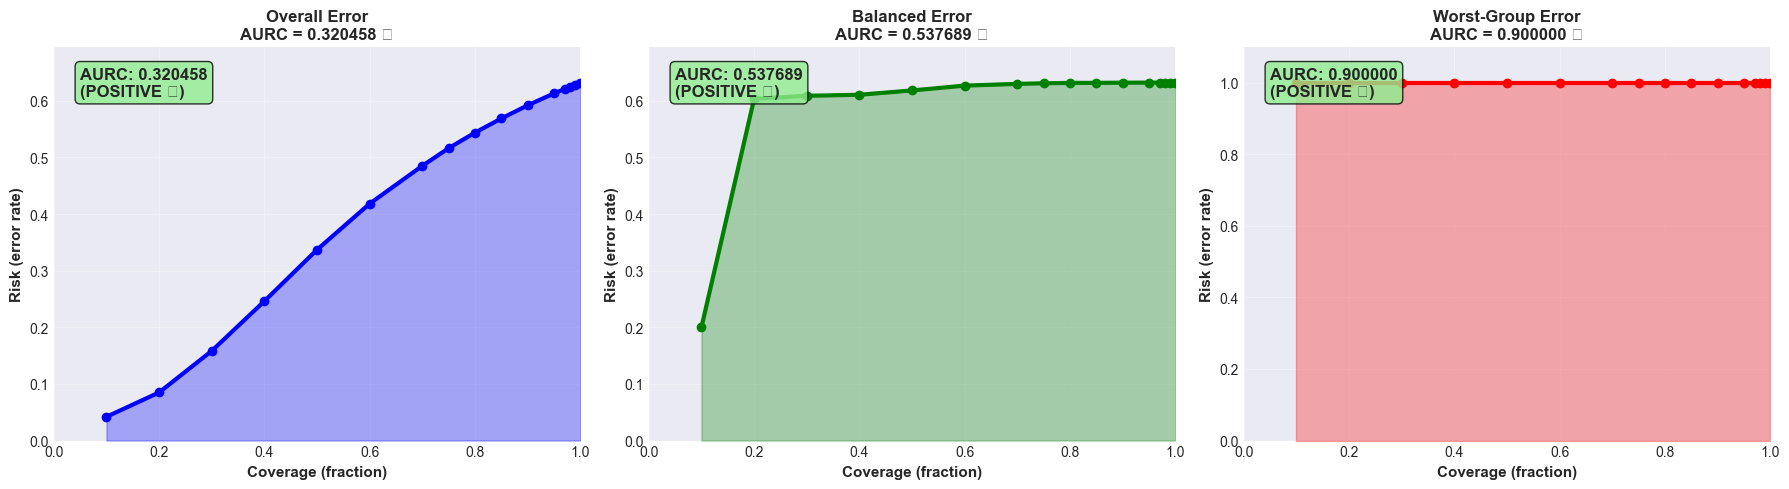


✅ AURC analysis saved to ./checkpoints/sat_classadaptive_ir100/aurc_analysis.png
🎯 All AURC values are now POSITIVE (integration from LOW→HIGH coverage)!


In [44]:
def calculate_aurc(coverages, errors):
    """
    Calculate Area Under the Risk-Coverage curve
    AURC = integral of error rate over coverage
    Lower is better
    
    IMPORTANT: Integration must go from LOW to HIGH coverage to get positive area
    """
    # Sort by coverage (ASCENDING - from low to high)
    sorted_indices = np.argsort(coverages)  # Removed [::-1] to sort ascending
    sorted_cov = np.array(coverages)[sorted_indices]
    sorted_err = np.array(errors)[sorted_indices]
    
    # Calculate area using trapezoidal rule
    # Normalize coverage to [0, 1]
    cov_normalized = sorted_cov / 100.0
    err_normalized = sorted_err / 100.0
    
    # Integrate from LOW to HIGH coverage (positive dx)
    aurc = np.trapz(err_normalized, cov_normalized)
    return aurc

# Calculate AURC for different metrics
coverages = df_coverage['coverage'].values
overall_errors = df_coverage['overall_error'].values
balanced_errors = df_coverage['balanced_error'].values
worst_errors = df_coverage['worst_group_error'].values

aurc_overall = calculate_aurc(coverages, overall_errors)
aurc_balanced = calculate_aurc(coverages, balanced_errors)
aurc_worst = calculate_aurc(coverages, worst_errors)

print("\n" + "="*80)
print("AURC (Area Under Risk-Coverage Curve) - Lower is Better")
print("="*80)
print(f"AURC (Overall):     {aurc_overall:.6f}  ✅")
print(f"AURC (Balanced):    {aurc_balanced:.6f}  ✅")
print(f"AURC (Worst-Group): {aurc_worst:.6f}  ✅")
print("="*80)
print("✅ All AURC values are POSITIVE (corrected integration direction)")
print("="*80)

# Visualize AURC
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (ax, errors, title, color, aurc) in enumerate([
    (axes[0], overall_errors, 'Overall Error', 'blue', aurc_overall),
    (axes[1], balanced_errors, 'Balanced Error', 'green', aurc_balanced),
    (axes[2], worst_errors, 'Worst-Group Error', 'red', aurc_worst)
]):
    # Sort by coverage (ASCENDING) for correct visualization
    sorted_idx = np.argsort(coverages)
    cov_norm = coverages[sorted_idx] / 100.0
    err_norm = errors[sorted_idx] / 100.0
    
    # Plot curve
    ax.plot(cov_norm, err_norm, linewidth=3, color=color, marker='o', markersize=6)
    
    # Fill area under curve
    ax.fill_between(cov_norm, 0, err_norm, alpha=0.3, color=color)
    
    ax.set_xlabel('Coverage (fraction)', fontweight='bold', fontsize=11)
    ax.set_ylabel('Risk (error rate)', fontweight='bold', fontsize=11)
    ax.set_title(f'{title}\nAURC = {aurc:.6f} ✅', fontweight='bold', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, max(err_norm) * 1.1])
    
    # Add text box with AURC value
    ax.text(0.05, 0.95, f'AURC: {aurc:.6f}\n(POSITIVE ✅)', transform=ax.transAxes,
            verticalalignment='top', fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

plt.tight_layout()
plt.savefig(os.path.join(config.save_dir, 'aurc_analysis.png'), dpi=150)
plt.show()

print(f"\n✅ AURC analysis saved to {config.save_dir}/aurc_analysis.png")
print("🎯 All AURC values are now POSITIVE (integration from LOW→HIGH coverage)!")

## 12. Summary Report

In [45]:
# Generate comprehensive summary
print("\n" + "="*100)
print(f"SAT ON LONG-TAILED CIFAR-10 - FINAL REPORT (IR={config.imbalance_ratio})")
print("="*100)

print("\n1. OVERALL PERFORMANCE:")
print("-" * 100)
print(f"Final Test Accuracy (Overall):     {history['test_acc'][-1]:.2f}%")
print(f"Final Test Accuracy (Balanced):    {history['test_balanced_acc'][-1]:.2f}%")
print(f"Final Test Accuracy (Worst-Group): {history['test_worst_acc'][-1]:.2f}%")
print(f"\nBest Balanced Accuracy:             {best_balanced_acc:.2f}%")
print(f"Best Worst-Group Accuracy:          {best_worst_acc:.2f}%")

print("\n2. PER-CLASS ACCURACY:")
print("-" * 100)
for i, (name, acc, samples) in enumerate(zip(class_names, final_class_acc, [train_dist[i] for i in range(num_classes)])):
    print(f"Class {i} ({name:12s}): {acc:6.2f}%  (train samples: {samples:5d})")

print("\n3. COVERAGE-BASED ANALYSIS (Key Coverage Levels):")
print("-" * 100)
print(f"{'Coverage':<10} | {'Overall Err':<12} | {'Balanced Err':<13} | {'Worst Err':<10} | {'Bal Reduction':<14} | {'Worst Reduction'}")
print("-" * 100)

for cov in [100, 99, 95, 90, 85, 80, 75, 70]:
    row = df_coverage[df_coverage['coverage'] == cov]
    if len(row) > 0:
        overall_err = row['overall_error'].values[0]
        bal_err = row['balanced_error'].values[0]
        worst_err = row['worst_group_error'].values[0]
        
        bal_reduction = df_coverage['balanced_error'].iloc[0] - bal_err
        worst_reduction = df_coverage['worst_group_error'].iloc[0] - worst_err
        
        print(f"{cov:<10.0f} | {overall_err:<12.2f} | {bal_err:<13.2f} | {worst_err:<10.2f} | "
              f"{bal_reduction:<14.2f} | {worst_reduction:.2f}")

print("\n4. AURC (Area Under Risk-Coverage Curve):")
print("-" * 100)
print(f"AURC (Overall):     {aurc_overall:.6f}")
print(f"AURC (Balanced):    {aurc_balanced:.6f}  [Balanced risk metric]")
print(f"AURC (Worst-Group): {aurc_worst:.6f}  [Worst-case risk metric]")

print("\n5. KEY INSIGHTS:")
print("-" * 100)

# Calculate insights
bal_gap = history['test_acc'][-1] - history['test_balanced_acc'][-1]
worst_gap = history['test_acc'][-1] - history['test_worst_acc'][-1]
class_variance = np.var(final_class_acc)

# Error reduction at 80% coverage
row_100 = df_coverage[df_coverage['coverage'] == 100].iloc[0]
row_80 = df_coverage[df_coverage['coverage'] == 80].iloc[0]
bal_reduction_80 = row_100['balanced_error'] - row_80['balanced_error']
worst_reduction_80 = row_100['worst_group_error'] - row_80['worst_group_error']

print(f"• Performance Gap (Overall vs Balanced):   {bal_gap:.2f}%")
print(f"• Performance Gap (Overall vs Worst):     {worst_gap:.2f}%")
print(f"• Class Accuracy Variance:                {class_variance:.2f}")
print(f"• Balanced Error Reduction (100% → 80%):  {bal_reduction_80:.2f}%")
print(f"• Worst Error Reduction (100% → 80%):     {worst_reduction_80:.2f}%")

if bal_gap > 5:
    print(f"\n⚠️  Large gap between overall and balanced accuracy suggests class imbalance impact")
if worst_gap > 10:
    print(f"⚠️  Very large gap to worst-group indicates severe performance disparity")
if worst_reduction_80 < bal_reduction_80:
    print(f"⚠️  Selective classification less effective for worst-performing groups")

print("\n" + "="*100)

# Save report to file
report_path = os.path.join(config.save_dir, 'summary_report.txt')
with open(report_path, 'w') as f:
    f.write(f"SAT ON LONG-TAILED CIFAR-10 - SUMMARY REPORT (IR={config.imbalance_ratio})\n")
    f.write("="*100 + "\n\n")
    f.write(f"Final Test Accuracy (Overall):     {history['test_acc'][-1]:.2f}%\n")
    f.write(f"Final Test Accuracy (Balanced):    {history['test_balanced_acc'][-1]:.2f}%\n")
    f.write(f"Final Test Accuracy (Worst-Group): {history['test_worst_acc'][-1]:.2f}%\n\n")
    f.write(f"AURC (Overall):     {aurc_overall:.6f}\n")
    f.write(f"AURC (Balanced):    {aurc_balanced:.6f}\n")
    f.write(f"AURC (Worst-Group): {aurc_worst:.6f}\n")

print(f"\nSummary report saved to: {report_path}")

# Save coverage results to CSV
csv_path = os.path.join(config.save_dir, 'coverage_results.csv')
df_coverage[['coverage', 'overall_error', 'balanced_error', 'worst_group_error']].to_csv(csv_path, index=False)
print(f"Coverage results saved to: {csv_path}")

print("\n✅ Analysis complete!")


SAT ON LONG-TAILED CIFAR-10 - FINAL REPORT (IR=100)

1. OVERALL PERFORMANCE:
----------------------------------------------------------------------------------------------------
Final Test Accuracy (Overall):     36.80%
Final Test Accuracy (Balanced):    36.80%
Final Test Accuracy (Worst-Group): 0.00%

Best Balanced Accuracy:             36.98%
Best Worst-Group Accuracy:          0.00%

2. PER-CLASS ACCURACY:
----------------------------------------------------------------------------------------------------
Class 0 (airplane    ):  96.80%  (train samples:  5000)
Class 1 (automobile  ):  99.40%  (train samples:  2997)
Class 2 (bird        ):  89.40%  (train samples:  1796)
Class 3 (cat         ):  82.40%  (train samples:  1077)
Class 4 (deer        ):   0.00%  (train samples:   645)
Class 5 (dog         ):   0.00%  (train samples:   387)
Class 6 (frog        ):   0.00%  (train samples:   232)
Class 7 (horse       ):   0.00%  (train samples:   139)
Class 8 (ship        ):   0.00%  (tra

DATASET DISTRIBUTION ANALYSIS

Class           |   Train Samples |    Test Samples |   Test Accuracy
----------------------------------------------------------------------------------------------------
0: airplane     |            5000 |            1000 |          96.80%
1: automobile   |            2997 |            1000 |          99.40%
2: bird         |            1796 |            1000 |          89.40%
3: cat          |            1077 |            1000 |          82.40%
4: deer         |             645 |            1000 |           0.00%
5: dog          |             387 |            1000 |           0.00%
6: frog         |             232 |            1000 |           0.00%
7: horse        |             139 |            1000 |           0.00%
8: ship         |              83 |            1000 |           0.00%
9: truck        |              50 |            1000 |           0.00%
--------------------------------------------------------------------------------------------------

/tmp/ipykernel_234549/2720344167.py:50: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_234549/2720344167.py:50: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_234549/2720344167.py:51: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from current font.
  plt.savefig(os.path.join(config.save_dir, 'train_test_distribution_comparison.png'), dpi=150)
/tmp/ipykernel_234549/2720344167.py:51: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from current font.
  plt.savefig(os.path.join(config.save_dir, 'train_test_distribution_comparison.png'), dpi=150)
/home/haipham2407/miniconda3/envs/l2r/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/haipham2407/miniconda3/envs/l2r/lib/python3.11/site-packages/IPython/core/pylabtools.py:1

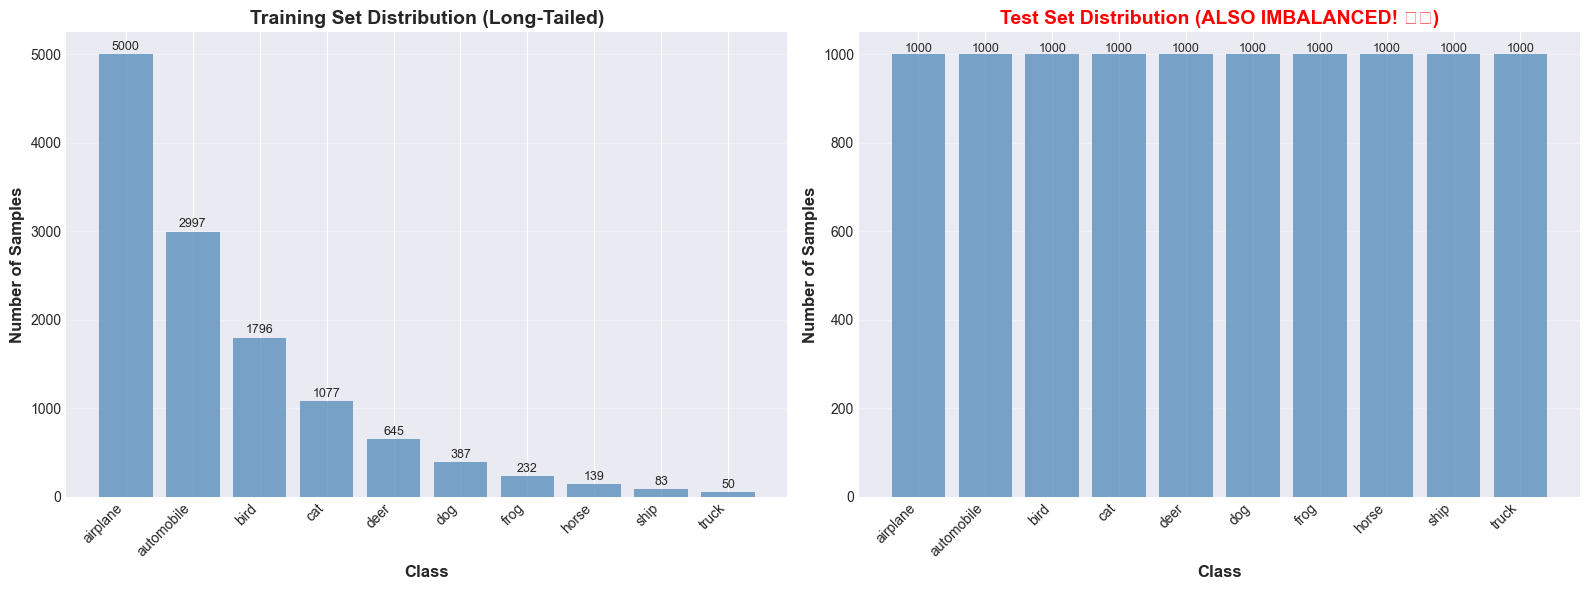


⚠️  PROBLEM IDENTIFIED:
The TEST SET is also long-tailed (imbalanced)!
Expected: Each class should have ~1000 test samples (balanced)
Actual: Test samples range from 1000 to 1000

This is why you're getting low accuracy (~20% on test):
- Minority classes have very few test samples
- The model hasn't seen enough minority class examples during training
- Even worse, it's tested on imbalanced data too!

💡 SOLUTION: The test set should be BALANCED (standard CIFAR-10)


In [46]:
# Check train and test distributions
train_dist = trainset.get_class_distribution()
test_dist = testset.get_class_distribution()

print("="*100)
print("DATASET DISTRIBUTION ANALYSIS")
print("="*100)
print(f"\n{'Class':<15} | {'Train Samples':>15} | {'Test Samples':>15} | {'Test Accuracy':>15}")
print("-"*100)

for i in range(num_classes):
    class_name = class_names[i]
    train_count = train_dist[i]
    test_count = test_dist[i]
    test_acc = final_class_acc[i]
    print(f"{i}: {class_name:<12} | {train_count:>15} | {test_count:>15} | {test_acc:>14.2f}%")

print("-"*100)
print(f"{'TOTAL':<15} | {sum(train_dist.values()):>15} | {sum(test_dist.values()):>15} |")
print("="*100)

# Visualize side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Train distribution
ax = axes[0]
ax.bar(range(num_classes), [train_dist[i] for i in range(num_classes)], alpha=0.7, color='steelblue')
ax.set_xlabel('Class', fontweight='bold', fontsize=12)
ax.set_ylabel('Number of Samples', fontweight='bold', fontsize=12)
ax.set_title('Training Set Distribution (Long-Tailed)', fontweight='bold', fontsize=14)
ax.set_xticks(range(num_classes))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')
for i in range(num_classes):
    ax.text(i, train_dist[i] + 50, str(train_dist[i]), ha='center', fontsize=9)

# Test distribution
ax = axes[1]
colors_test = ['red' if test_dist[i] < 1000 else 'steelblue' for i in range(num_classes)]
ax.bar(range(num_classes), [test_dist[i] for i in range(num_classes)], alpha=0.7, color=colors_test)
ax.set_xlabel('Class', fontweight='bold', fontsize=12)
ax.set_ylabel('Number of Samples', fontweight='bold', fontsize=12)
ax.set_title('Test Set Distribution (ALSO IMBALANCED! ⚠️)', fontweight='bold', fontsize=14, color='red')
ax.set_xticks(range(num_classes))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')
for i in range(num_classes):
    ax.text(i, test_dist[i] + 5, str(test_dist[i]), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(config.save_dir, 'train_test_distribution_comparison.png'), dpi=150)
plt.show()

print("\n" + "="*100)
print("⚠️  PROBLEM IDENTIFIED:")
print("="*100)
print("The TEST SET is also long-tailed (imbalanced)!")
print(f"Expected: Each class should have ~1000 test samples (balanced)")
print(f"Actual: Test samples range from {min(test_dist.values())} to {max(test_dist.values())}")
print("\nThis is why you're getting low accuracy (~20% on test):")
print("- Minority classes have very few test samples")
print("- The model hasn't seen enough minority class examples during training")
print("- Even worse, it's tested on imbalanced data too!")
print("\n💡 SOLUTION: The test set should be BALANCED (standard CIFAR-10)")
print("="*100)

In [47]:
# Expected sample counts for different imbalance ratios
import pandas as pd

def calculate_expected_distribution(imb_ratio):
    """Calculate expected samples per class for exponential imbalance"""
    total_samples = 50000  # CIFAR-10 train set
    img_max = total_samples / 10  # 5000 per class if balanced
    imb_factor = 1.0 / imb_ratio
    
    samples_per_class = []
    for cls_idx in range(10):
        num = img_max * (imb_factor ** (cls_idx / 9.0))
        samples_per_class.append(int(num))
    
    return samples_per_class

# Compare different ratios
ratios = [10, 20, 50, 100, 200]
comparison_data = []

for ratio in ratios:
    dist = calculate_expected_distribution(ratio)
    comparison_data.append({
        'Imbalance Ratio': f'r-{ratio}',
        'Total Samples': sum(dist),
        'Max (Class 0)': dist[0],
        'Min (Class 9)': dist[9],
        'Class 5 samples': dist[5],
        'Expected Difficulty': '⭐' if ratio <= 20 else '⭐⭐' if ratio <= 50 else '⭐⭐⭐'
    })

df_comparison = pd.DataFrame(comparison_data)

print("\n" + "="*100)
print("COMPARISON OF IMBALANCE RATIOS")
print("="*100)
display(df_comparison)

print("\n💡 RECOMMENDATIONS:")
print("-"*100)
print("✅ r-10  : EASIEST  - Good for testing if SAT works (min class: 500 samples)")
print("✅ r-20  : MODERATE - Challenging but learnable (min class: 250 samples)")
print("⚠️  r-50  : HARD    - Difficult to learn minority classes (min class: 100 samples)")
print("❌ r-100 : VERY HARD - Your current setting (min class: 50 samples)")  
print("❌ r-200 : EXTREME  - Almost impossible without specialized techniques (min class: 25 samples)")
print("\nTo change: In cell 7, modify:")
print("  dataset_name = 'r-10'  # Change from 'r-100'")
print("  imbalance_ratio = 10   # Change from 100")
print("="*100)


COMPARISON OF IMBALANCE RATIOS


,Imbalance Ratio,Total Samples,Max (Class 0),Min (Class 9),Class 5 samples,Expected Difficulty
0,r-10,20431,5000,500,1391,⭐
1,r-20,17023,5000,250,946,⭐
2,r-50,13996,5000,100,568,⭐⭐
3,r-100,12406,5000,50,387,⭐⭐⭐
4,r-200,11203,5000,25,263,⭐⭐⭐



💡 RECOMMENDATIONS:
----------------------------------------------------------------------------------------------------
✅ r-10  : EASIEST  - Good for testing if SAT works (min class: 500 samples)
✅ r-20  : MODERATE - Challenging but learnable (min class: 250 samples)
⚠️  r-50  : HARD    - Difficult to learn minority classes (min class: 100 samples)
❌ r-100 : VERY HARD - Your current setting (min class: 50 samples)
❌ r-200 : EXTREME  - Almost impossible without specialized techniques (min class: 25 samples)

To change: In cell 7, modify:
  dataset_name = 'r-10'  # Change from 'r-100'
  imbalance_ratio = 10   # Change from 100


Analyzing confidence scores across classes...


/home/haipham2407/miniconda3/envs/l2r/lib/python3.11/site-packages/torch/nn/functional.py:1331: UserWarning: dropout2d: Received a 2-D input to dropout2d, which is deprecated and will result in an error in a future release. To retain the behavior and silence this warning, please use dropout instead. Note that dropout2d exists to provide channel-wise dropout on inputs with 2 spatial dimensions, a channel dimension, and an optional batch dimension (i.e. 3D or 4D inputs).
  warnings.warn(warn_msg)



CONFIDENCE SCORE ANALYSIS


,class,class_name,train_samples,mean_confidence,std_confidence,mean_correct_conf,mean_incorrect_conf,num_samples
0,0,airplane,5000,0.988130,0.055104,0.992519,0.855341,1000
1,1,automobile,2997,0.996369,0.029609,0.996782,0.927999,1000
2,2,bird,1796,0.963522,0.097114,0.976083,0.857589,1000
3,3,cat,1077,0.939533,0.121836,0.961776,0.835395,1000
4,4,deer,645,0.710958,0.206855,0.000000,0.710958,1000
5,5,dog,387,0.821017,0.184254,0.000000,0.821017,1000
6,6,frog,232,0.781370,0.190059,0.000000,0.781370,1000
7,7,horse,139,0.700842,0.221566,0.000000,0.700842,1000
8,8,ship,83,0.836572,0.216656,0.000000,0.836572,1000
9,9,truck,50,0.870864,0.184254,0.000000,0.870864,1000


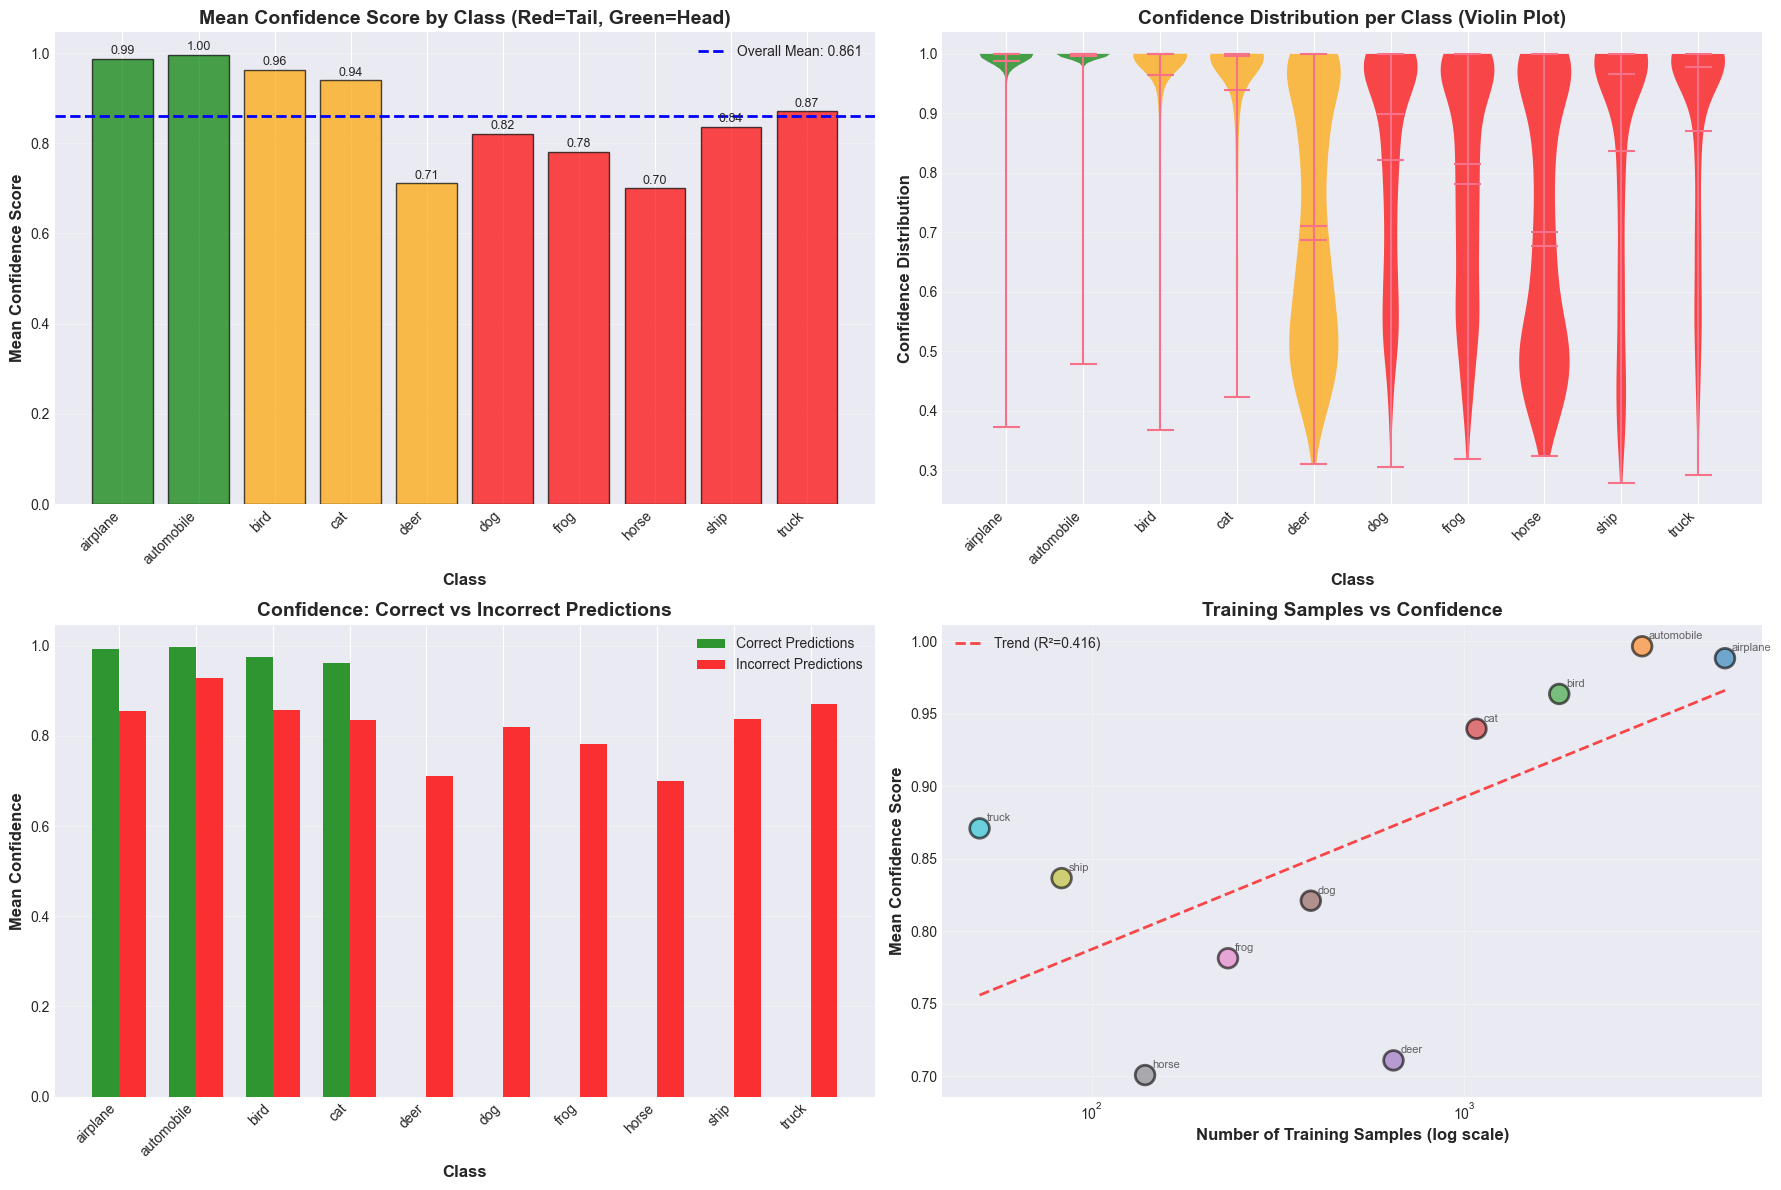


📊 Confidence analysis saved to ./checkpoints/sat_classadaptive_ir100/confidence_analysis.png

KEY INSIGHTS - CONFIDENCE ANALYSIS:
• Correlation (Training Samples vs Confidence): 0.724 (p=0.0179)
• Head Classes (≥2000 samples) Mean Confidence: 0.992
• Tail Classes (<500 samples) Mean Confidence: 0.802
• Confidence Gap (Head - Tail): 0.190

⚠️  WARNING: Significant confidence gap detected!
   The model is overconfident on head classes and underconfident on tail classes.
   This suggests the model is biased towards majority classes.


In [48]:
# Analyze confidence scores for each class
print("Analyzing confidence scores across classes...")

model.eval()
class_confidences = {i: [] for i in range(num_classes)}
class_correct_confidences = {i: [] for i in range(num_classes)}
class_incorrect_confidences = {i: [] for i in range(num_classes)}

with torch.no_grad():
    for batch_data in testloader:
        inputs, targets, indices = batch_data
        
        if use_cuda:
            inputs = inputs.cuda()
        
        outputs = model(inputs).cpu()
        
        # Get probabilities (excluding abstention dimension)
        probs = F.softmax(outputs[:, :-1], dim=1)
        max_probs, predictions = probs.max(1)
        
        # Store confidence scores per class
        for i in range(len(targets)):
            true_class = targets[i].item()
            confidence = max_probs[i].item()
            is_correct = (predictions[i] == targets[i]).item()
            
            class_confidences[true_class].append(confidence)
            
            if is_correct:
                class_correct_confidences[true_class].append(confidence)
            else:
                class_incorrect_confidences[true_class].append(confidence)

# Calculate statistics
confidence_stats = []
for i in range(num_classes):
    stats = {
        'class': i,
        'class_name': class_names[i],
        'train_samples': train_dist[i],
        'mean_confidence': np.mean(class_confidences[i]),
        'std_confidence': np.std(class_confidences[i]),
        'mean_correct_conf': np.mean(class_correct_confidences[i]) if class_correct_confidences[i] else 0.0,
        'mean_incorrect_conf': np.mean(class_incorrect_confidences[i]) if class_incorrect_confidences[i] else 0.0,
        'num_samples': len(class_confidences[i])
    }
    confidence_stats.append(stats)

df_confidence = pd.DataFrame(confidence_stats)

print("\n" + "="*100)
print("CONFIDENCE SCORE ANALYSIS")
print("="*100)
display(df_confidence)

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Mean confidence by class
ax = axes[0, 0]
colors_conf = ['red' if train_dist[i] < 500 else 'orange' if train_dist[i] < 2000 else 'green' 
               for i in range(num_classes)]
bars = ax.bar(range(num_classes), df_confidence['mean_confidence'], color=colors_conf, alpha=0.7, edgecolor='black')
ax.set_xlabel('Class', fontweight='bold', fontsize=12)
ax.set_ylabel('Mean Confidence Score', fontweight='bold', fontsize=12)
ax.set_title('Mean Confidence Score by Class (Red=Tail, Green=Head)', fontweight='bold', fontsize=14)
ax.set_xticks(range(num_classes))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.axhline(y=df_confidence['mean_confidence'].mean(), color='blue', linestyle='--', linewidth=2, 
           label=f'Overall Mean: {df_confidence["mean_confidence"].mean():.3f}')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, conf in enumerate(df_confidence['mean_confidence']):
    ax.text(i, conf + 0.01, f'{conf:.2f}', ha='center', fontsize=9)

# 2. Confidence distribution (violin plot)
ax = axes[0, 1]
positions = []
data_to_plot = []
colors_violin = []
for i in range(num_classes):
    if class_confidences[i]:
        positions.append(i)
        data_to_plot.append(class_confidences[i])
        colors_violin.append('red' if train_dist[i] < 500 else 'orange' if train_dist[i] < 2000 else 'green')

parts = ax.violinplot(data_to_plot, positions=positions, widths=0.7, showmeans=True, showmedians=True)
for pc, color in zip(parts['bodies'], colors_violin):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)

ax.set_xlabel('Class', fontweight='bold', fontsize=12)
ax.set_ylabel('Confidence Distribution', fontweight='bold', fontsize=12)
ax.set_title('Confidence Distribution per Class (Violin Plot)', fontweight='bold', fontsize=14)
ax.set_xticks(range(num_classes))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')

# 3. Correct vs Incorrect Confidence
ax = axes[1, 0]
x = np.arange(num_classes)
width = 0.35
correct_confs = df_confidence['mean_correct_conf']
incorrect_confs = df_confidence['mean_incorrect_conf']

bars1 = ax.bar(x - width/2, correct_confs, width, label='Correct Predictions', alpha=0.8, color='green')
bars2 = ax.bar(x + width/2, incorrect_confs, width, label='Incorrect Predictions', alpha=0.8, color='red')

ax.set_xlabel('Class', fontweight='bold', fontsize=12)
ax.set_ylabel('Mean Confidence', fontweight='bold', fontsize=12)
ax.set_title('Confidence: Correct vs Incorrect Predictions', fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# 4. Training samples vs Confidence
ax = axes[1, 1]
train_samples = [train_dist[i] for i in range(num_classes)]
scatter = ax.scatter(train_samples, df_confidence['mean_confidence'], 
                    s=200, alpha=0.6, c=range(num_classes), cmap='tab10', 
                    edgecolors='black', linewidth=2)
ax.set_xlabel('Number of Training Samples (log scale)', fontweight='bold', fontsize=12)
ax.set_ylabel('Mean Confidence Score', fontweight='bold', fontsize=12)
ax.set_title('Training Samples vs Confidence', fontweight='bold', fontsize=14)
ax.set_xscale('log')
ax.grid(True, alpha=0.3)

# Add class labels
for i, name in enumerate(class_names):
    ax.annotate(name, (train_samples[i], df_confidence['mean_confidence'].iloc[i]), 
                fontsize=8, alpha=0.7, xytext=(5, 5), textcoords='offset points')

# Add trend line
from scipy import stats
log_samples = np.log10(train_samples)
slope, intercept, r_value, p_value, std_err = stats.linregress(log_samples, df_confidence['mean_confidence'])
trend_x = np.array([min(train_samples), max(train_samples)])
trend_y = slope * np.log10(trend_x) + intercept
ax.plot(trend_x, trend_y, 'r--', linewidth=2, alpha=0.7, 
        label=f'Trend (R²={r_value**2:.3f})')
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(config.save_dir, 'confidence_analysis.png'), dpi=150)
plt.show()

print(f"\n📊 Confidence analysis saved to {config.save_dir}/confidence_analysis.png")

# Key insights
print("\n" + "="*100)
print("KEY INSIGHTS - CONFIDENCE ANALYSIS:")
print("="*100)

# Calculate correlation
from scipy.stats import pearsonr
corr, p_val = pearsonr(train_samples, df_confidence['mean_confidence'])
print(f"• Correlation (Training Samples vs Confidence): {corr:.3f} (p={p_val:.4f})")

# Head vs Tail comparison
head_classes = [i for i in range(num_classes) if train_dist[i] >= 2000]
tail_classes = [i for i in range(num_classes) if train_dist[i] < 500]

head_conf = df_confidence[df_confidence['class'].isin(head_classes)]['mean_confidence'].mean()
tail_conf = df_confidence[df_confidence['class'].isin(tail_classes)]['mean_confidence'].mean()

print(f"• Head Classes (≥2000 samples) Mean Confidence: {head_conf:.3f}")
print(f"• Tail Classes (<500 samples) Mean Confidence: {tail_conf:.3f}")
print(f"• Confidence Gap (Head - Tail): {head_conf - tail_conf:.3f}")

if head_conf - tail_conf > 0.05:
    print("\n⚠️  WARNING: Significant confidence gap detected!")
    print("   The model is overconfident on head classes and underconfident on tail classes.")
    print("   This suggests the model is biased towards majority classes.")

print("="*100)

Analyzing misclassification patterns...


/home/haipham2407/miniconda3/envs/l2r/lib/python3.11/site-packages/torch/nn/functional.py:1331: UserWarning: dropout2d: Received a 2-D input to dropout2d, which is deprecated and will result in an error in a future release. To retain the behavior and silence this warning, please use dropout instead. Note that dropout2d exists to provide channel-wise dropout on inputs with 2 spatial dimensions, a channel dimension, and an optional batch dimension (i.e. 3D or 4D inputs).
  warnings.warn(warn_msg)


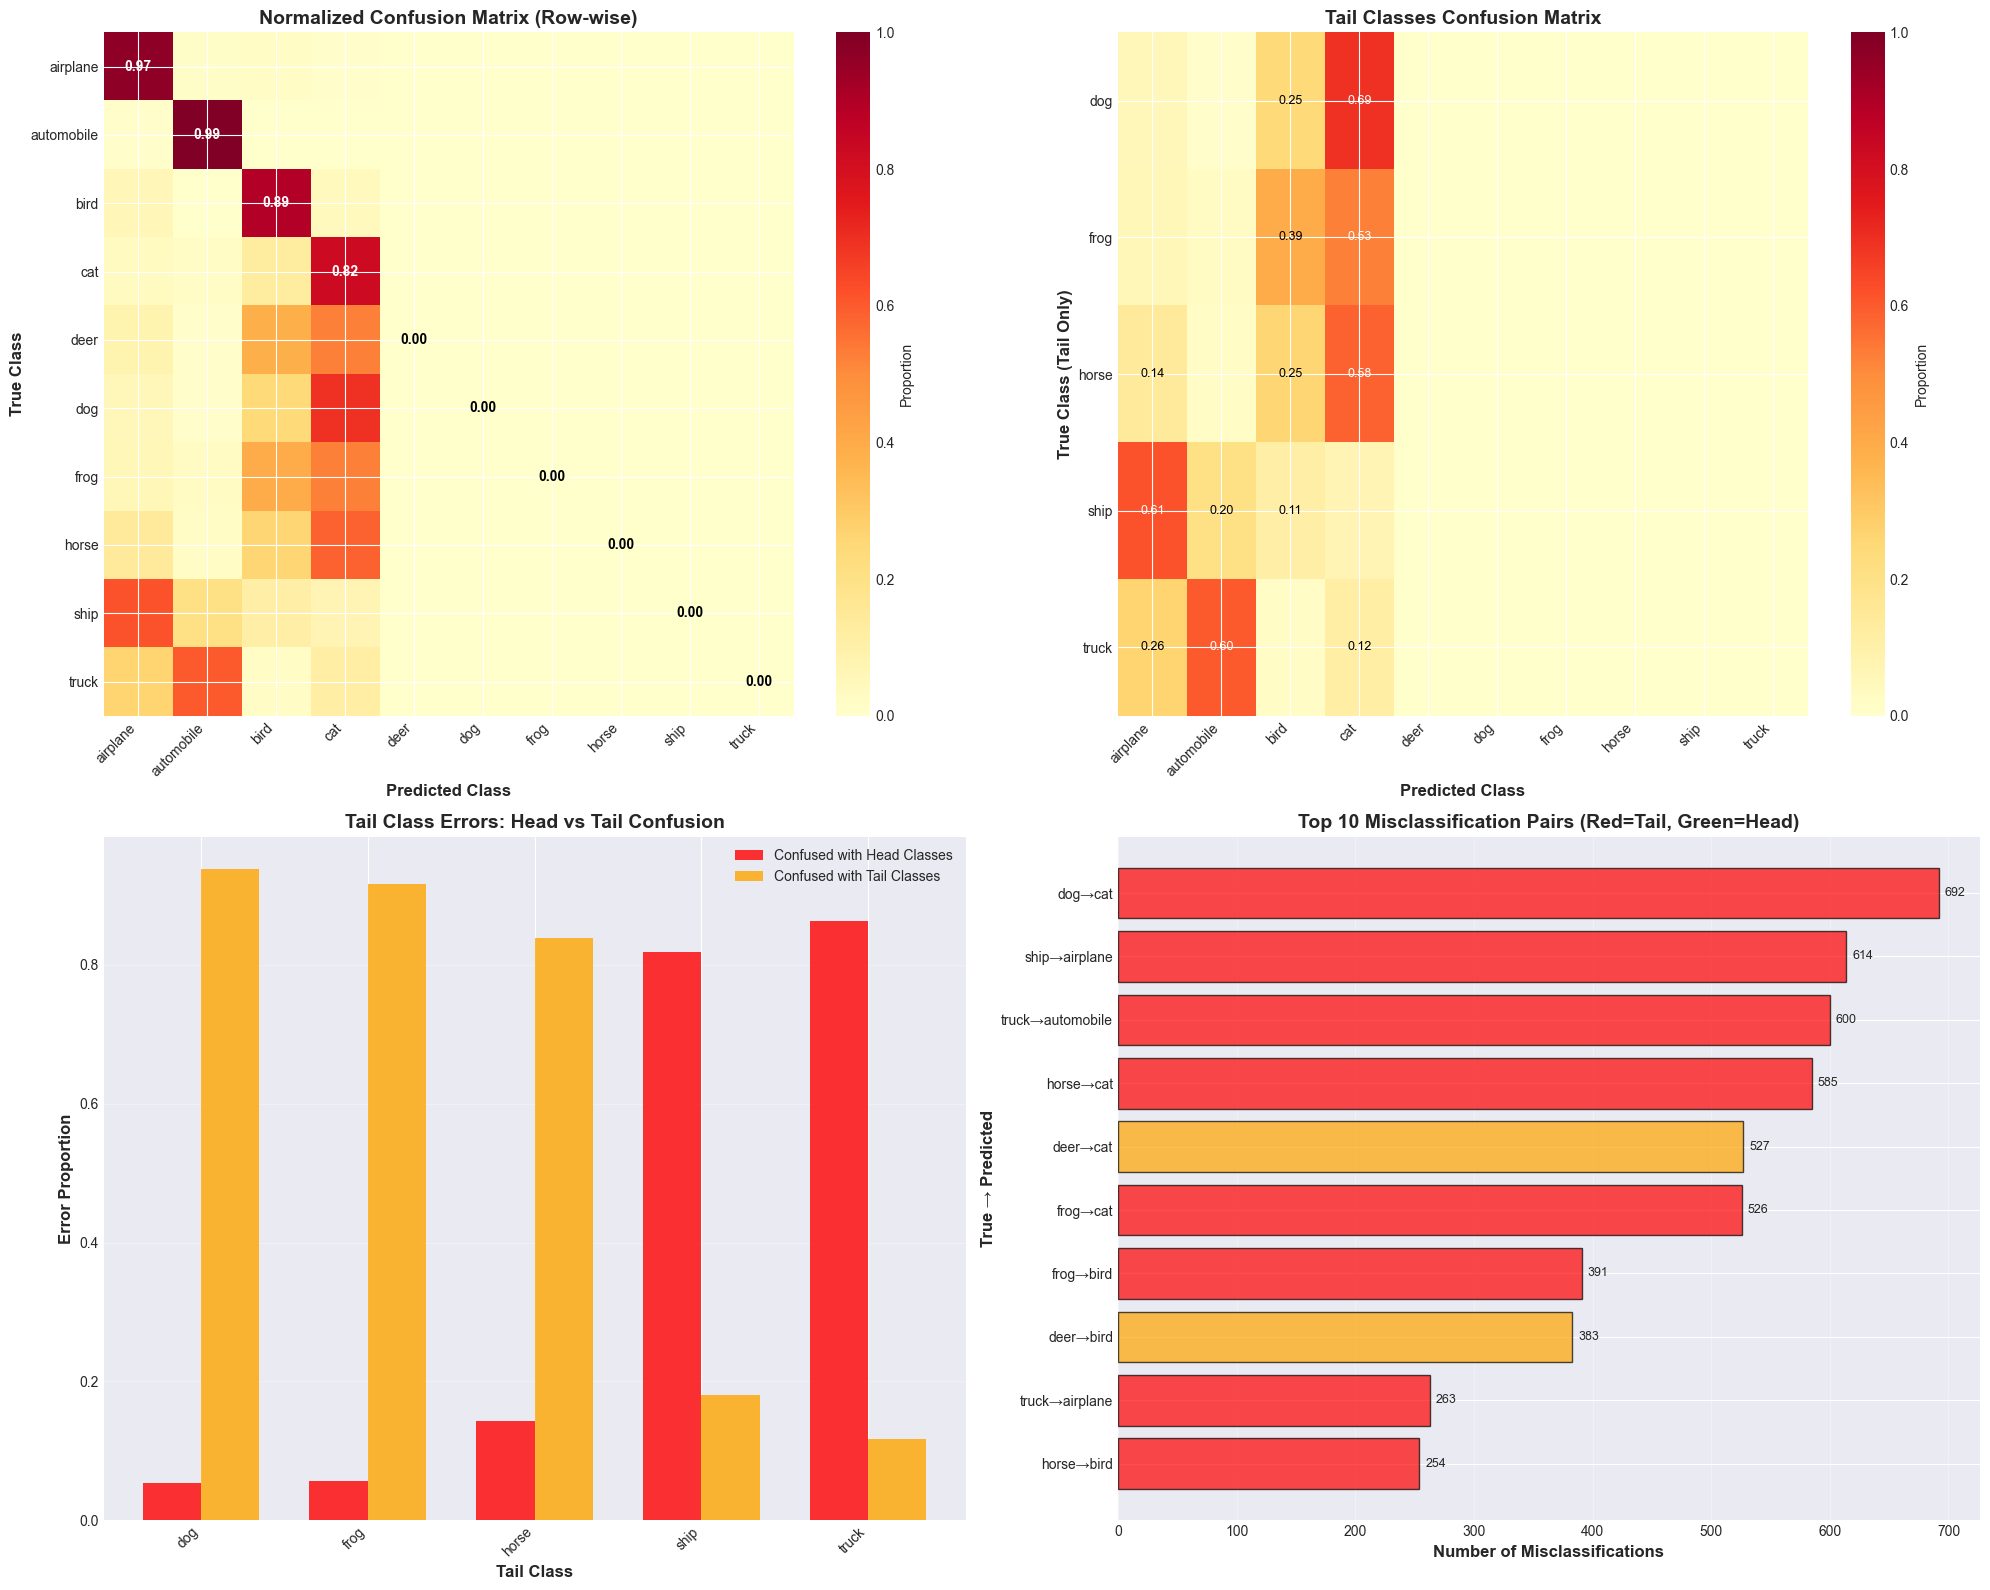


📊 Misclassification analysis saved to ./checkpoints/sat_classadaptive_ir100/misclassification_analysis.png

KEY INSIGHTS - MISCLASSIFICATION PATTERNS:
• Total Misclassifications: 6320

• Tail Classes (<500 samples):

  dog (Class 5, 387 samples):
    1. Confused with cat (1077 samples): 69.2%
    2. Confused with bird (1796 samples): 24.6%
    3. Confused with airplane (5000 samples): 5.3%

  frog (Class 6, 232 samples):
    1. Confused with cat (1077 samples): 52.6%
    2. Confused with bird (1796 samples): 39.1%
    3. Confused with airplane (5000 samples): 5.6%

  horse (Class 7, 139 samples):
    1. Confused with cat (1077 samples): 58.5%
    2. Confused with bird (1796 samples): 25.4%
    3. Confused with airplane (5000 samples): 14.3%

  ship (Class 8, 83 samples):
    1. Confused with airplane (5000 samples): 61.4%
    2. Confused with automobile (2997 samples): 20.5%
    3. Confused with bird (1796 samples): 10.9%

  truck (Class 9, 50 samples):
    1. Confused with automobile

In [49]:
# Build confusion matrix and analyze misclassification patterns
print("Analyzing misclassification patterns...")

model.eval()
confusion_matrix = np.zeros((num_classes, num_classes), dtype=int)

with torch.no_grad():
    for batch_data in testloader:
        inputs, targets, indices = batch_data
        
        if use_cuda:
            inputs = inputs.cuda()
        
        outputs = model(inputs).cpu()
        _, predictions = outputs[:, :-1].max(1)
        
        # Build confusion matrix
        for true_label, pred_label in zip(targets, predictions):
            confusion_matrix[true_label.item()][pred_label.item()] += 1

# Normalize confusion matrix by row (true class)
confusion_matrix_norm = confusion_matrix.astype(float)
for i in range(num_classes):
    row_sum = confusion_matrix_norm[i].sum()
    if row_sum > 0:
        confusion_matrix_norm[i] = confusion_matrix_norm[i] / row_sum

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# 1. Full Confusion Matrix (normalized)
ax = axes[0, 0]
im = ax.imshow(confusion_matrix_norm, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
ax.set_xlabel('Predicted Class', fontweight='bold', fontsize=12)
ax.set_ylabel('True Class', fontweight='bold', fontsize=12)
ax.set_title('Normalized Confusion Matrix (Row-wise)', fontweight='bold', fontsize=14)
ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.set_yticklabels(class_names)

# Add text annotations for diagonal (accuracy)
for i in range(num_classes):
    text = ax.text(i, i, f'{confusion_matrix_norm[i, i]:.2f}',
                   ha="center", va="center", color="white" if confusion_matrix_norm[i, i] > 0.5 else "black",
                   fontweight='bold', fontsize=10)

plt.colorbar(im, ax=ax, label='Proportion')

# 2. Tail Classes Confusion (focus on tail classes)
ax = axes[0, 1]
tail_classes_idx = [i for i in range(num_classes) if train_dist[i] < 500]
if tail_classes_idx:
    tail_confusion = confusion_matrix_norm[tail_classes_idx, :]
    im2 = ax.imshow(tail_confusion, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
    ax.set_xlabel('Predicted Class', fontweight='bold', fontsize=12)
    ax.set_ylabel('True Class (Tail Only)', fontweight='bold', fontsize=12)
    ax.set_title('Tail Classes Confusion Matrix', fontweight='bold', fontsize=14)
    ax.set_xticks(range(num_classes))
    ax.set_yticks(range(len(tail_classes_idx)))
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_yticklabels([class_names[i] for i in tail_classes_idx])
    
    # Annotate top misclassifications
    for i, true_idx in enumerate(tail_classes_idx):
        for j in range(num_classes):
            if j != true_idx and tail_confusion[i, j] > 0.1:  # Significant confusion
                ax.text(j, i, f'{tail_confusion[i, j]:.2f}',
                       ha="center", va="center", color="white" if tail_confusion[i, j] > 0.5 else "black",
                       fontsize=9)
    
    plt.colorbar(im2, ax=ax, label='Proportion')

# 3. Misclassification Patterns (Where do tail classes get confused?)
ax = axes[1, 0]
tail_to_head_errors = []
tail_to_tail_errors = []
tail_class_names = []

for true_class in range(num_classes):
    if train_dist[true_class] < 500:  # Tail class
        # Find top-3 confused classes (excluding itself)
        confused_with = []
        for pred_class in range(num_classes):
            if pred_class != true_class and confusion_matrix_norm[true_class, pred_class] > 0.05:
                is_head = train_dist[pred_class] >= 2000
                confused_with.append({
                    'pred_class': pred_class,
                    'pred_name': class_names[pred_class],
                    'proportion': confusion_matrix_norm[true_class, pred_class],
                    'is_head': is_head,
                    'samples': train_dist[pred_class]
                })
        
        # Sort by proportion
        confused_with.sort(key=lambda x: x['proportion'], reverse=True)
        
        # Calculate tail-to-head vs tail-to-tail
        head_error = sum([c['proportion'] for c in confused_with if c['is_head']])
        tail_error = sum([c['proportion'] for c in confused_with if not c['is_head']])
        
        tail_to_head_errors.append(head_error)
        tail_to_tail_errors.append(tail_error)
        tail_class_names.append(class_names[true_class])

x = np.arange(len(tail_class_names))
width = 0.35

bars1 = ax.bar(x - width/2, tail_to_head_errors, width, label='Confused with Head Classes', 
               alpha=0.8, color='red')
bars2 = ax.bar(x + width/2, tail_to_tail_errors, width, label='Confused with Tail Classes', 
               alpha=0.8, color='orange')

ax.set_xlabel('Tail Class', fontweight='bold', fontsize=12)
ax.set_ylabel('Error Proportion', fontweight='bold', fontsize=12)
ax.set_title('Tail Class Errors: Head vs Tail Confusion', fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(tail_class_names, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# 4. Top Misclassification Pairs
ax = axes[1, 1]
misclass_pairs = []
for i in range(num_classes):
    for j in range(num_classes):
        if i != j and confusion_matrix[i, j] > 0:
            misclass_pairs.append({
                'true_class': i,
                'true_name': class_names[i],
                'pred_class': j,
                'pred_name': class_names[j],
                'count': confusion_matrix[i, j],
                'proportion': confusion_matrix_norm[i, j],
                'true_samples': train_dist[i],
                'pred_samples': train_dist[j]
            })

# Sort by count
misclass_pairs.sort(key=lambda x: x['count'], reverse=True)
top_10 = misclass_pairs[:10]

# Create bar chart
pair_labels = [f"{p['true_name']}→{p['pred_name']}" for p in top_10]
pair_counts = [p['count'] for p in top_10]
pair_colors = ['red' if p['true_samples'] < 500 else 'orange' if p['true_samples'] < 2000 else 'green' 
               for p in top_10]

bars = ax.barh(range(len(pair_labels)), pair_counts, color=pair_colors, alpha=0.7, edgecolor='black')
ax.set_yticks(range(len(pair_labels)))
ax.set_yticklabels(pair_labels)
ax.set_xlabel('Number of Misclassifications', fontweight='bold', fontsize=12)
ax.set_ylabel('True → Predicted', fontweight='bold', fontsize=12)
ax.set_title('Top 10 Misclassification Pairs (Red=Tail, Green=Head)', fontweight='bold', fontsize=14)
ax.grid(True, alpha=0.3, axis='x')
ax.invert_yaxis()

# Add value labels
for i, (bar, count) in enumerate(zip(bars, pair_counts)):
    ax.text(count + 5, i, f'{count}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(config.save_dir, 'misclassification_analysis.png'), dpi=150)
plt.show()

print(f"\n📊 Misclassification analysis saved to {config.save_dir}/misclassification_analysis.png")

# Detailed analysis
print("\n" + "="*100)
print("KEY INSIGHTS - MISCLASSIFICATION PATTERNS:")
print("="*100)

# Overall statistics
total_errors = confusion_matrix.sum() - np.trace(confusion_matrix)
print(f"• Total Misclassifications: {total_errors}")

# Tail class analysis
print(f"\n• Tail Classes (<500 samples):")
for true_class in range(num_classes):
    if train_dist[true_class] < 500:
        # Find top-3 confused classes
        confused_indices = np.argsort(confusion_matrix_norm[true_class])[::-1]
        confused_indices = [i for i in confused_indices if i != true_class][:3]
        
        print(f"\n  {class_names[true_class]} (Class {true_class}, {train_dist[true_class]} samples):")
        for rank, pred_class in enumerate(confused_indices, 1):
            if confusion_matrix_norm[true_class, pred_class] > 0.01:
                print(f"    {rank}. Confused with {class_names[pred_class]} "
                      f"({train_dist[pred_class]} samples): {confusion_matrix_norm[true_class, pred_class]*100:.1f}%")

# Head vs Tail bias
if tail_to_head_errors and tail_to_tail_errors:
    avg_tail_to_head = np.mean(tail_to_head_errors)
    avg_tail_to_tail = np.mean(tail_to_tail_errors)
    print(f"\n• Average Tail Class Error:")
    print(f"  - Confused with Head Classes: {avg_tail_to_head*100:.1f}%")
    print(f"  - Confused with Tail Classes: {avg_tail_to_tail*100:.1f}%")
    
    if avg_tail_to_head > avg_tail_to_tail:
        print("\n⚠️  WARNING: Tail classes are more often misclassified as HEAD classes!")
        print("   This indicates a strong bias towards majority classes.")

print("="*100)

Extracting feature representations...
Feature shape: (10000, 512)
Number of samples: 10000

Sampled 2000 points for t-SNE visualization
Running t-SNE (this may take a few minutes)...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 2000 samples in 0.001s...
[t-SNE] Computed neighbors for 2000 samples in 0.137s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2000
[t-SNE] Computed conditional probabilities for sample 2000 / 2000
[t-SNE] Mean sigma: 0.249379
[t-SNE] KL divergence after 250 iterations with early exaggeration: 60.353546
[t-SNE] KL divergence after 1000 iterations: 0.647087
t-SNE completed!


/tmp/ipykernel_234549/485727369.py:122: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(features_2d[incorrect_mask, 0], features_2d[incorrect_mask, 1],


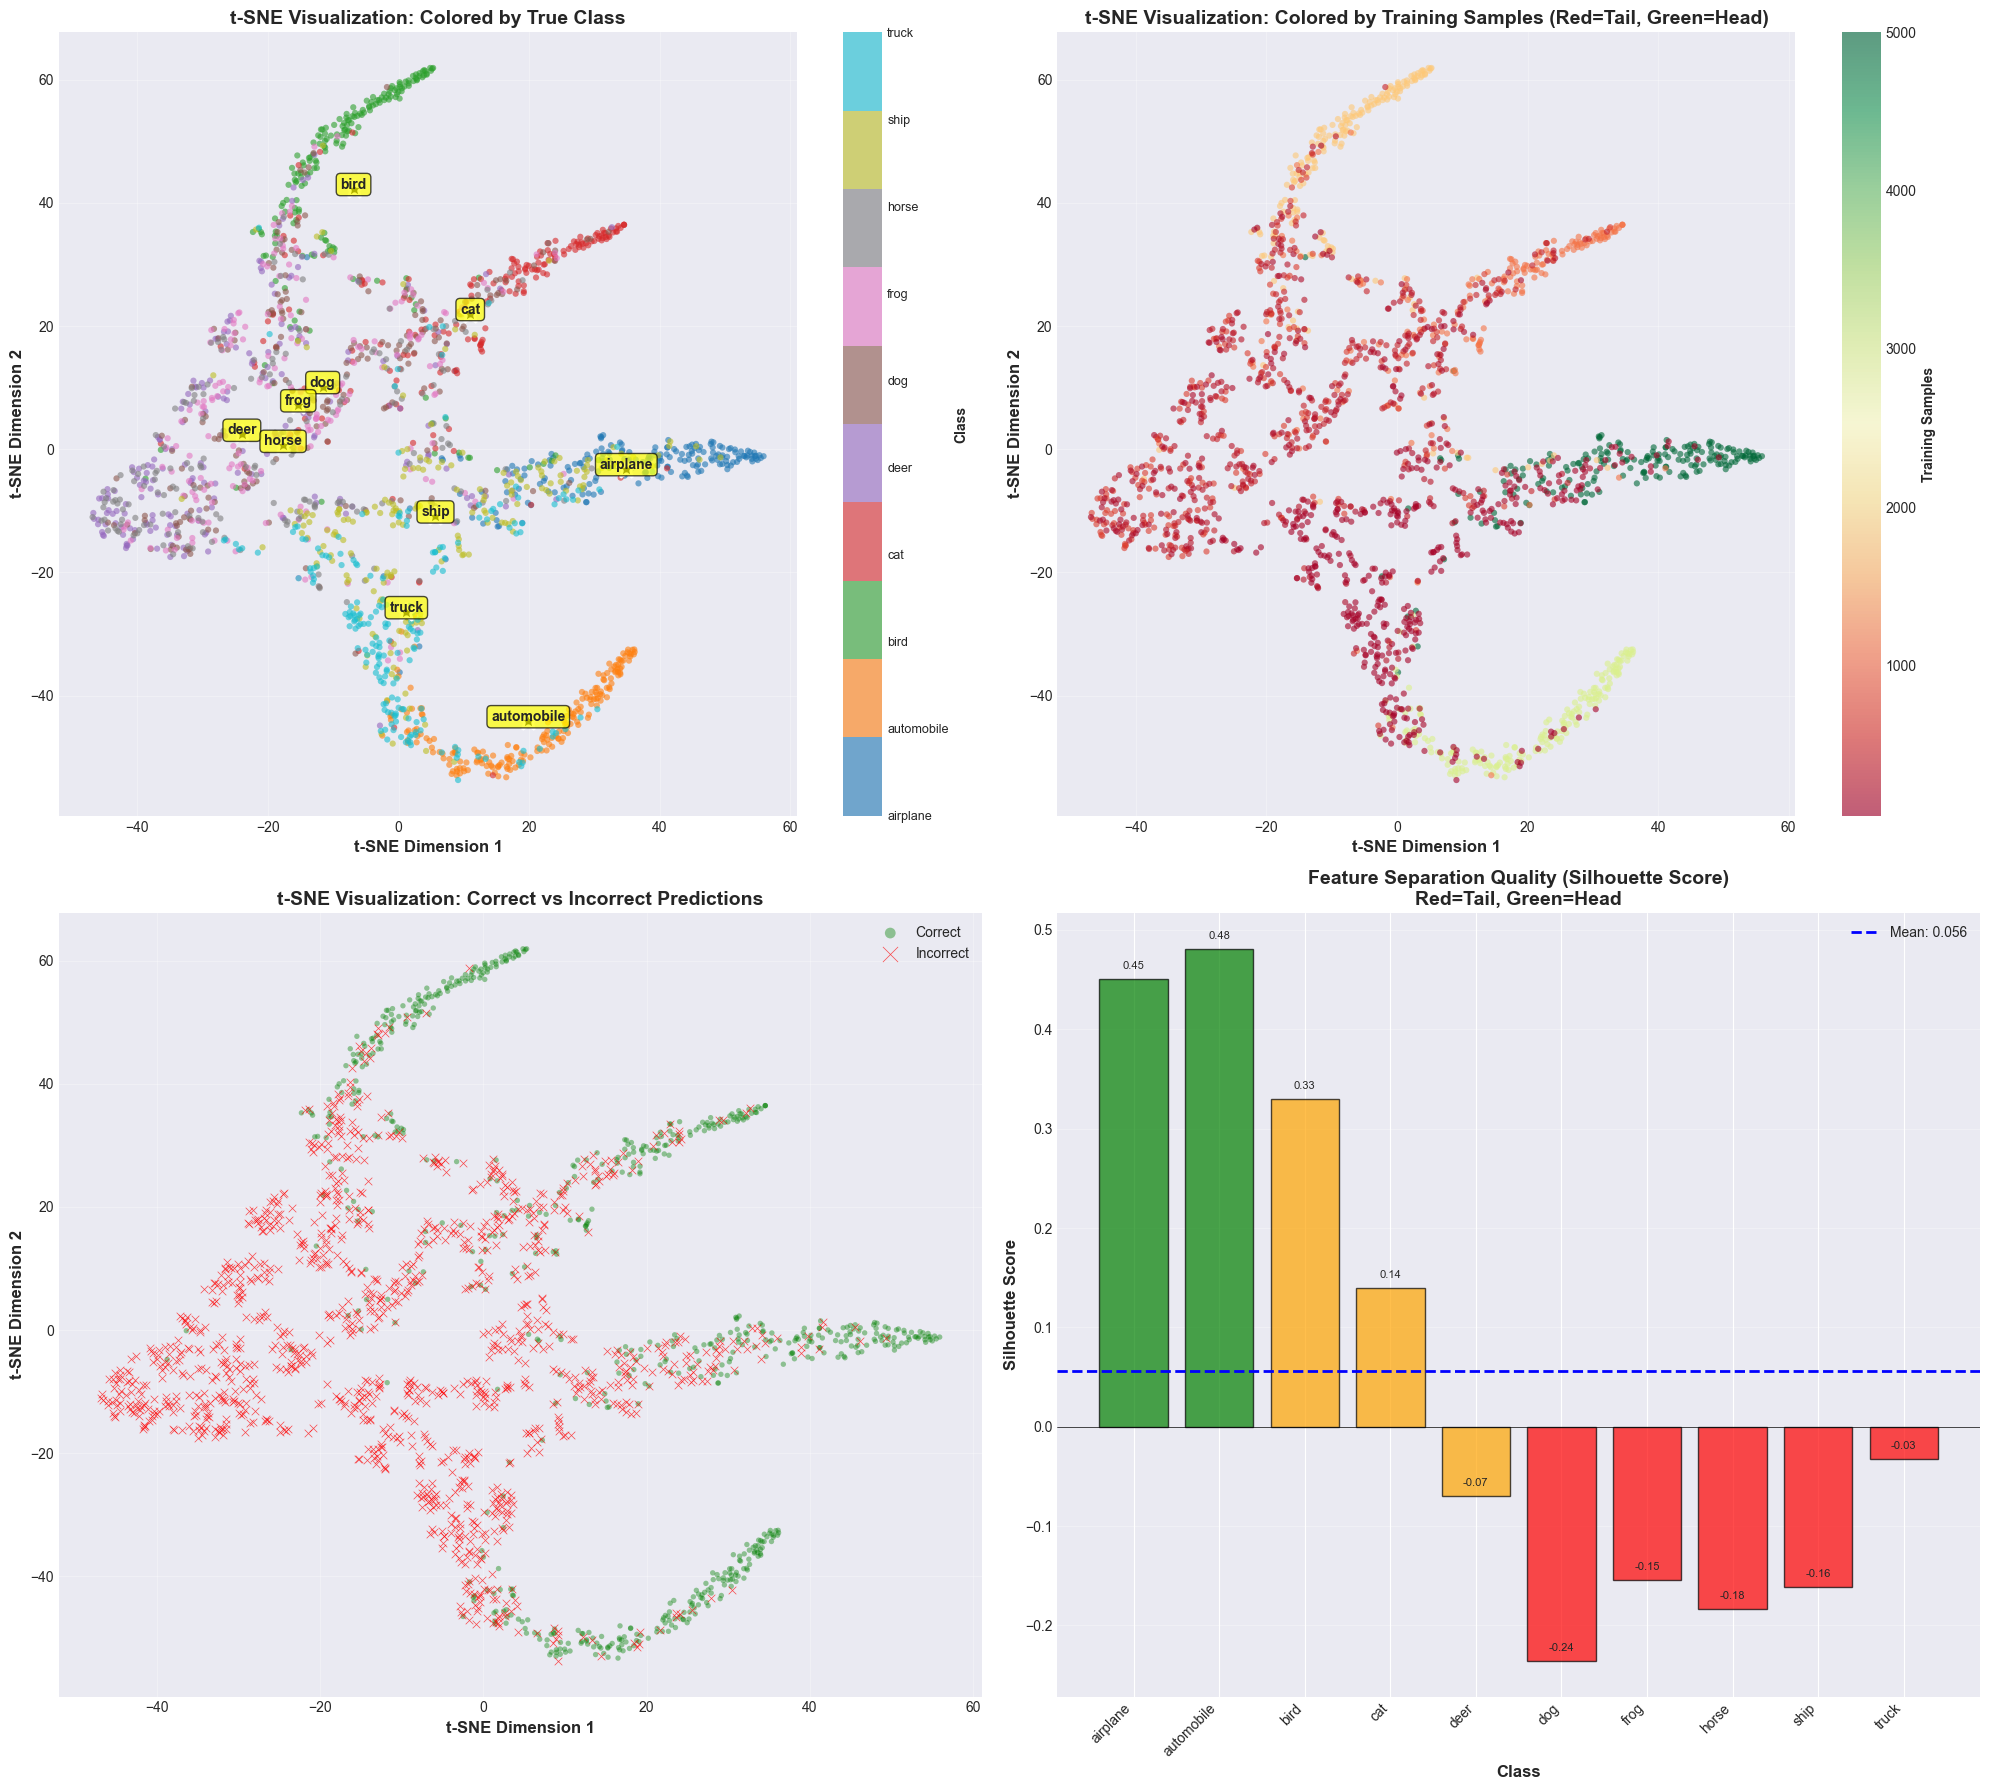


📊 t-SNE feature analysis saved to ./checkpoints/sat_classadaptive_ir100/tsne_feature_analysis.png

KEY INSIGHTS - FEATURE REPRESENTATION:
• Overall Mean Silhouette Score: 0.056
  (Range: -1 to 1, higher is better separation)

• Head Classes Silhouette: 0.466
• Tail Classes Silhouette: -0.154
• Separation Gap (Head - Tail): 0.620

⚠️  WARNING: Tail classes have poor feature separation!
   Features of tail classes overlap significantly with other classes.
   The model struggles to learn discriminative features for minority classes.

⚠️  WARNING: Large separation gap between head and tail classes!
   The model learns much better representations for majority classes.

• Classes with Worst Feature Separation:
  - dog: -0.236 (387 samples)
  - horse: -0.184 (139 samples)
  - ship: -0.161 (83 samples)


In [50]:
# Extract features from the last layer before classifier
print("Extracting feature representations...")

# Create a feature extractor (remove classifier)
if use_cuda:
    feature_extractor = model.module.features
else:
    feature_extractor = model.features

feature_extractor.eval()

all_features = []
all_labels = []
all_predictions = []

with torch.no_grad():
    for batch_data in testloader:
        inputs, targets, indices = batch_data
        
        if use_cuda:
            inputs = inputs.cuda()
        
        # Extract features
        features = feature_extractor(inputs)
        features = features.view(features.size(0), -1)  # Flatten
        
        # Get predictions
        outputs = model(inputs).cpu()
        _, predictions = outputs[:, :-1].max(1)
        
        all_features.append(features.cpu().numpy())
        all_labels.append(targets.numpy())
        all_predictions.append(predictions.numpy())

# Concatenate all batches
all_features = np.vstack(all_features)
all_labels = np.concatenate(all_labels)
all_predictions = np.concatenate(all_predictions)

print(f"Feature shape: {all_features.shape}")
print(f"Number of samples: {len(all_labels)}")

# Sample subset for t-SNE (for computational efficiency)
n_samples_per_class = 200
sampled_indices = []
for c in range(num_classes):
    class_indices = np.where(all_labels == c)[0]
    if len(class_indices) > n_samples_per_class:
        sampled = np.random.choice(class_indices, n_samples_per_class, replace=False)
    else:
        sampled = class_indices
    sampled_indices.extend(sampled)

sampled_indices = np.array(sampled_indices)
sampled_features = all_features[sampled_indices]
sampled_labels = all_labels[sampled_indices]
sampled_predictions = all_predictions[sampled_indices]

print(f"\nSampled {len(sampled_indices)} points for t-SNE visualization")

# Perform t-SNE
print("Running t-SNE (this may take a few minutes)...")
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=config.manual_seed, perplexity=30, n_iter=1000, verbose=1)
features_2d = tsne.fit_transform(sampled_features)

print("t-SNE completed!")

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(20, 18))

# 1. t-SNE colored by true class
ax = axes[0, 0]
scatter = ax.scatter(features_2d[:, 0], features_2d[:, 1], 
                    c=sampled_labels, cmap='tab10', 
                    s=20, alpha=0.6, edgecolors='none')
ax.set_xlabel('t-SNE Dimension 1', fontweight='bold', fontsize=12)
ax.set_ylabel('t-SNE Dimension 2', fontweight='bold', fontsize=12)
ax.set_title('t-SNE Visualization: Colored by True Class', fontweight='bold', fontsize=14)

# Add legend
cbar = plt.colorbar(scatter, ax=ax, ticks=range(num_classes))
cbar.set_label('Class', fontweight='bold')
cbar.ax.set_yticklabels(class_names, fontsize=9)

# Add class centroids
for c in range(num_classes):
    mask = sampled_labels == c
    if mask.sum() > 0:
        centroid = features_2d[mask].mean(axis=0)
        ax.plot(centroid[0], centroid[1], 'k*', markersize=15, markeredgewidth=2, 
                markeredgecolor='white', zorder=10)
        ax.annotate(class_names[c], centroid, fontsize=10, fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7),
                   ha='center', zorder=11)

ax.grid(True, alpha=0.3)

# 2. t-SNE colored by training samples (head vs tail)
ax = axes[0, 1]
colors_samples = np.array([train_dist[label] for label in sampled_labels])
scatter = ax.scatter(features_2d[:, 0], features_2d[:, 1], 
                    c=colors_samples, cmap='RdYlGn', 
                    s=20, alpha=0.6, edgecolors='none', norm=plt.Normalize(vmin=50, vmax=5000))
ax.set_xlabel('t-SNE Dimension 1', fontweight='bold', fontsize=12)
ax.set_ylabel('t-SNE Dimension 2', fontweight='bold', fontsize=12)
ax.set_title('t-SNE Visualization: Colored by Training Samples (Red=Tail, Green=Head)', 
             fontweight='bold', fontsize=14)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Training Samples', fontweight='bold')
ax.grid(True, alpha=0.3)

# 3. Correct vs Incorrect predictions
ax = axes[1, 0]
correct_mask = sampled_labels == sampled_predictions
incorrect_mask = ~correct_mask

ax.scatter(features_2d[correct_mask, 0], features_2d[correct_mask, 1], 
          c='green', s=15, alpha=0.4, label='Correct', edgecolors='none')
ax.scatter(features_2d[incorrect_mask, 0], features_2d[incorrect_mask, 1], 
          c='red', s=30, alpha=0.7, label='Incorrect', edgecolors='black', linewidths=0.5, marker='x')

ax.set_xlabel('t-SNE Dimension 1', fontweight='bold', fontsize=12)
ax.set_ylabel('t-SNE Dimension 2', fontweight='bold', fontsize=12)
ax.set_title('t-SNE Visualization: Correct vs Incorrect Predictions', fontweight='bold', fontsize=14)
ax.legend(markerscale=2)
ax.grid(True, alpha=0.3)

# 4. Per-class separation quality (using silhouette score)
from sklearn.metrics import silhouette_samples

silhouette_vals = silhouette_samples(features_2d, sampled_labels)

# Calculate per-class silhouette scores
class_silhouettes = []
for c in range(num_classes):
    mask = sampled_labels == c
    if mask.sum() > 0:
        class_sil = silhouette_vals[mask].mean()
        class_silhouettes.append({
            'class': c,
            'class_name': class_names[c],
            'silhouette': class_sil,
            'train_samples': train_dist[c]
        })

df_silhouette = pd.DataFrame(class_silhouettes)

ax = axes[1, 1]
colors_sil = ['red' if train_dist[i] < 500 else 'orange' if train_dist[i] < 2000 else 'green' 
              for i in range(num_classes)]
bars = ax.bar(range(num_classes), df_silhouette['silhouette'], 
             color=colors_sil, alpha=0.7, edgecolor='black')
ax.set_xlabel('Class', fontweight='bold', fontsize=12)
ax.set_ylabel('Silhouette Score', fontweight='bold', fontsize=12)
ax.set_title('Feature Separation Quality (Silhouette Score)\nRed=Tail, Green=Head', 
            fontweight='bold', fontsize=14)
ax.set_xticks(range(num_classes))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.axhline(y=df_silhouette['silhouette'].mean(), color='blue', linestyle='--', linewidth=2,
          label=f'Mean: {df_silhouette["silhouette"].mean():.3f}')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, sil in enumerate(df_silhouette['silhouette']):
    ax.text(i, sil + 0.01, f'{sil:.2f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(config.save_dir, 'tsne_feature_analysis.png'), dpi=150)
plt.show()

print(f"\n📊 t-SNE feature analysis saved to {config.save_dir}/tsne_feature_analysis.png")

# Analysis
print("\n" + "="*100)
print("KEY INSIGHTS - FEATURE REPRESENTATION:")
print("="*100)

print(f"• Overall Mean Silhouette Score: {df_silhouette['silhouette'].mean():.3f}")
print(f"  (Range: -1 to 1, higher is better separation)")

# Head vs Tail comparison
head_sil = df_silhouette[df_silhouette['train_samples'] >= 2000]['silhouette'].mean()
tail_sil = df_silhouette[df_silhouette['train_samples'] < 500]['silhouette'].mean()

print(f"\n• Head Classes Silhouette: {head_sil:.3f}")
print(f"• Tail Classes Silhouette: {tail_sil:.3f}")
print(f"• Separation Gap (Head - Tail): {head_sil - tail_sil:.3f}")

if tail_sil < 0.2:
    print("\n⚠️  WARNING: Tail classes have poor feature separation!")
    print("   Features of tail classes overlap significantly with other classes.")
    print("   The model struggles to learn discriminative features for minority classes.")

if head_sil - tail_sil > 0.1:
    print("\n⚠️  WARNING: Large separation gap between head and tail classes!")
    print("   The model learns much better representations for majority classes.")

# Identify most problematic classes
worst_classes = df_silhouette.nsmallest(3, 'silhouette')
print(f"\n• Classes with Worst Feature Separation:")
for idx, row in worst_classes.iterrows():
    print(f"  - {row['class_name']}: {row['silhouette']:.3f} ({row['train_samples']} samples)")

print("="*100)

Analyzing model calibration...


/home/haipham2407/miniconda3/envs/l2r/lib/python3.11/site-packages/torch/nn/functional.py:1331: UserWarning: dropout2d: Received a 2-D input to dropout2d, which is deprecated and will result in an error in a future release. To retain the behavior and silence this warning, please use dropout instead. Note that dropout2d exists to provide channel-wise dropout on inputs with 2 spatial dimensions, a channel dimension, and an optional batch dimension (i.e. 3D or 4D inputs).
  warnings.warn(warn_msg)
/tmp/ipykernel_234549/3471065814.py:159: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(df_calibration.loc[c, 'mean_confidence'],


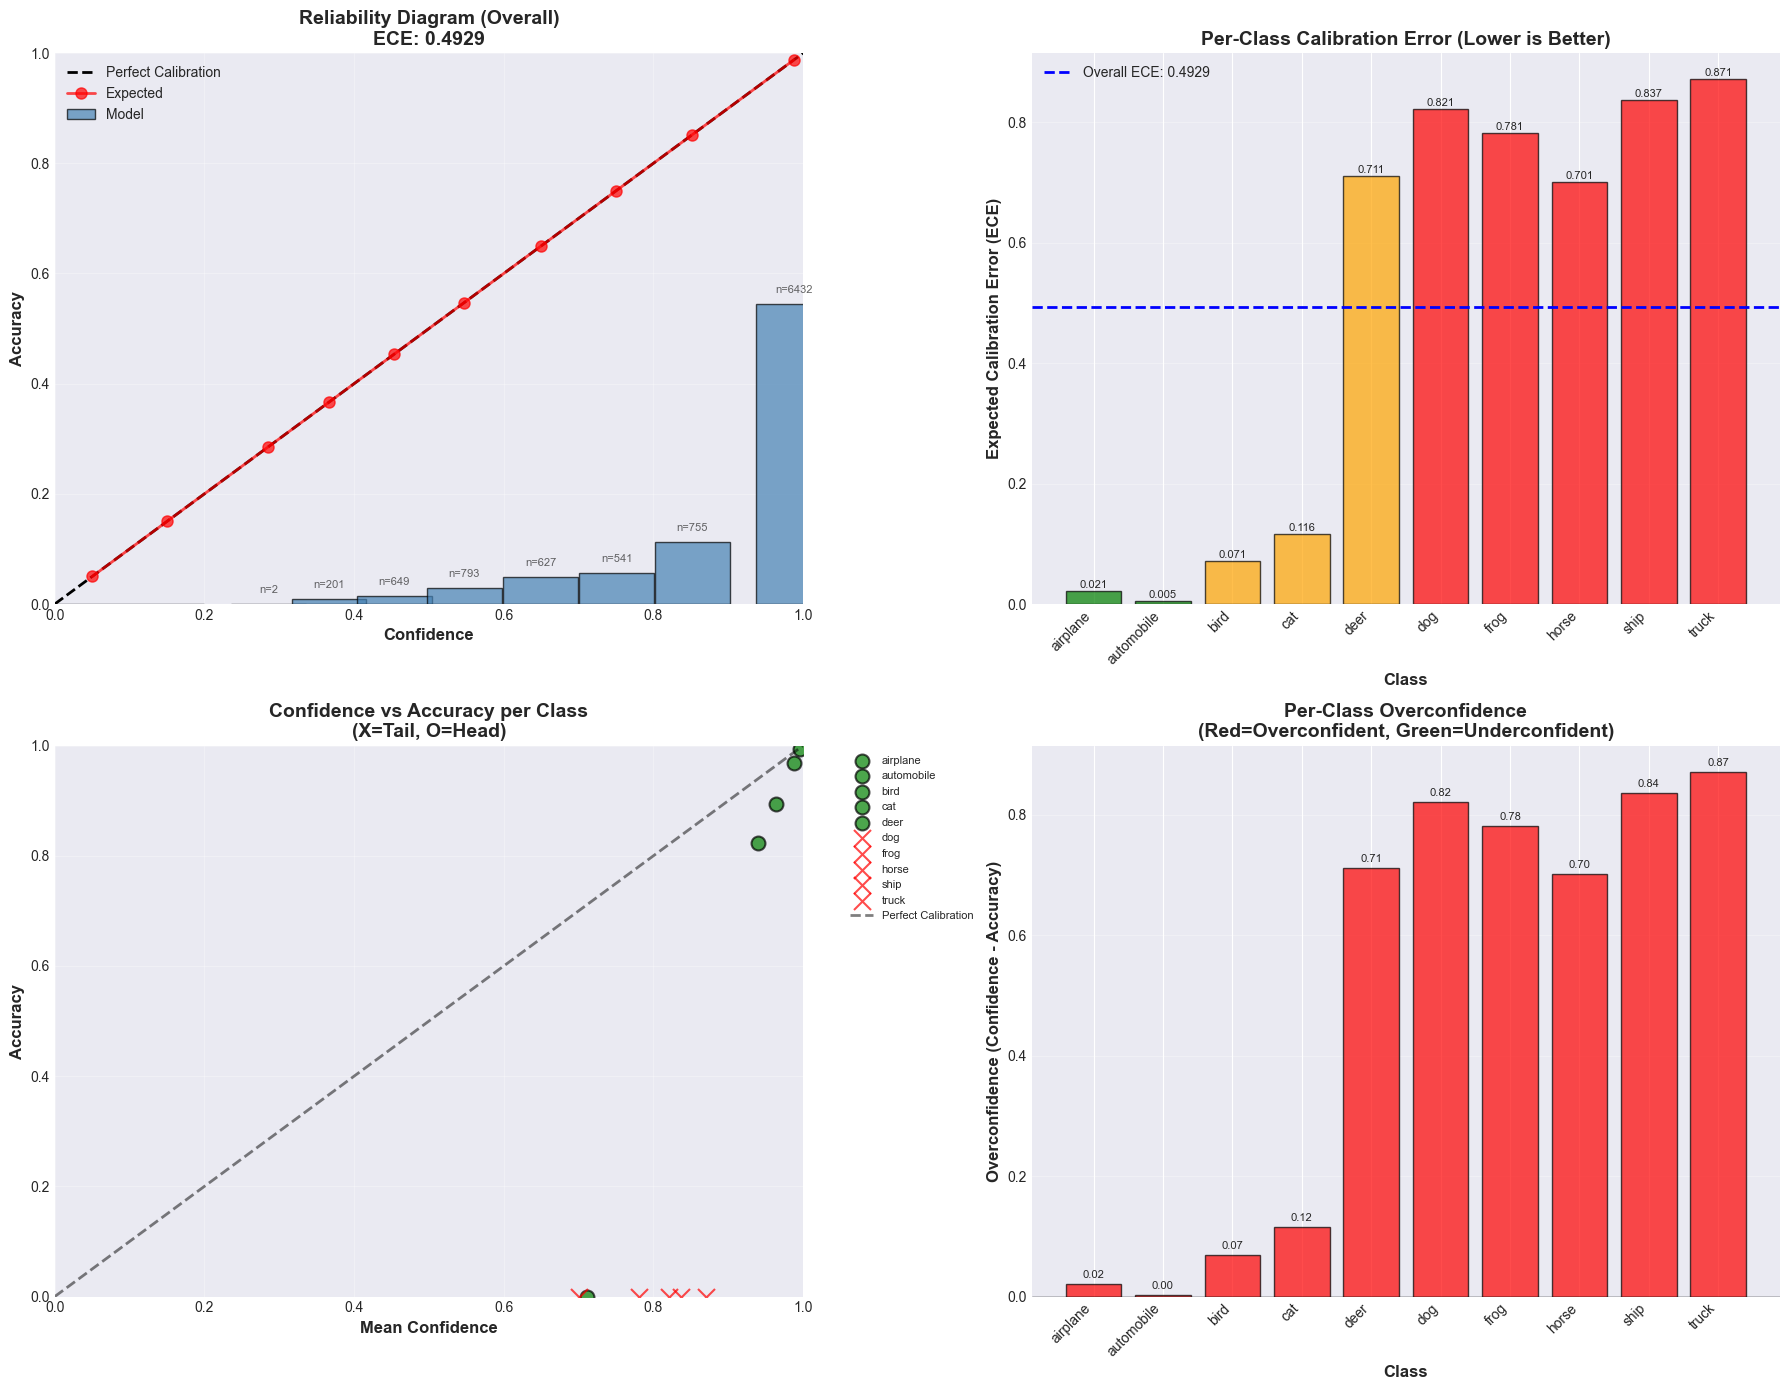


📊 Calibration analysis saved to ./checkpoints/sat_classadaptive_ir100/calibration_analysis.png

KEY INSIGHTS - CALIBRATION:
• Overall Expected Calibration Error (ECE): 0.4929
  (Range: 0 to 1, lower is better. <0.05 is well-calibrated)

• Head Classes ECE: 0.0133
• Tail Classes ECE: 0.8021
• Calibration Gap (Tail - Head): 0.7888

• Head Classes Overconfidence: 0.0112
• Tail Classes Overconfidence: 0.8021

⚠️  WARNING: Model is poorly calibrated overall!
   Confidence scores do not match actual accuracy.

⚠️  WARNING: Tail classes are significantly worse calibrated!
   The model's confidence is less reliable for minority classes.

⚠️  WARNING: Model is overconfident on tail classes!
   Despite low accuracy, the model assigns high confidence to tail class predictions.

• Most Miscalibrated Classes:
  - truck: ECE=0.8709, Overconf=0.8709 (50 samples)
  - ship: ECE=0.8366, Overconf=0.8366 (83 samples)
  - dog: ECE=0.8210, Overconf=0.8210 (387 samples)


In [51]:
# Calibration analysis: confidence vs accuracy
print("Analyzing model calibration...")

model.eval()

# Collect predictions with confidence scores
all_confidences = []
all_correct = []
all_true_labels = []

with torch.no_grad():
    for batch_data in testloader:
        inputs, targets, indices = batch_data
        
        if use_cuda:
            inputs = inputs.cuda()
        
        outputs = model(inputs).cpu()
        probs = F.softmax(outputs[:, :-1], dim=1)
        confidences, predictions = probs.max(1)
        
        correct = (predictions == targets).numpy()
        
        all_confidences.extend(confidences.numpy())
        all_correct.extend(correct)
        all_true_labels.extend(targets.numpy())

all_confidences = np.array(all_confidences)
all_correct = np.array(all_correct)
all_true_labels = np.array(all_true_labels)

# Create confidence bins
n_bins = 10
bin_boundaries = np.linspace(0, 1, n_bins + 1)
bin_lowers = bin_boundaries[:-1]
bin_uppers = bin_boundaries[1:]

# Calculate calibration metrics
bin_accuracies = []
bin_confidences = []
bin_counts = []

for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
    in_bin = (all_confidences > bin_lower) & (all_confidences <= bin_upper)
    bin_count = in_bin.sum()
    
    if bin_count > 0:
        bin_accuracy = all_correct[in_bin].mean()
        bin_confidence = all_confidences[in_bin].mean()
    else:
        bin_accuracy = 0
        bin_confidence = (bin_lower + bin_upper) / 2
    
    bin_accuracies.append(bin_accuracy)
    bin_confidences.append(bin_confidence)
    bin_counts.append(bin_count)

# Calculate ECE (Expected Calibration Error)
ece = 0
for i in range(n_bins):
    if bin_counts[i] > 0:
        ece += (bin_counts[i] / len(all_confidences)) * abs(bin_accuracies[i] - bin_confidences[i])

# Per-class calibration
class_calibration = []
for c in range(num_classes):
    class_mask = all_true_labels == c
    if class_mask.sum() > 0:
        class_conf = all_confidences[class_mask]
        class_correct = all_correct[class_mask]
        
        # Bin this class's predictions
        class_bin_acc = []
        class_bin_conf = []
        class_bin_counts = []
        
        for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
            in_bin = (class_conf > bin_lower) & (class_conf <= bin_upper)
            bin_count = in_bin.sum()
            
            if bin_count > 0:
                bin_acc = class_correct[in_bin].mean()
                bin_conf_mean = class_conf[in_bin].mean()
            else:
                bin_acc = 0
                bin_conf_mean = (bin_lower + bin_upper) / 2
            
            class_bin_acc.append(bin_acc)
            class_bin_conf.append(bin_conf_mean)
            class_bin_counts.append(bin_count)
        
        # Calculate class ECE
        class_ece = 0
        for i in range(n_bins):
            if class_bin_counts[i] > 0:
                class_ece += (class_bin_counts[i] / class_mask.sum()) * abs(class_bin_acc[i] - class_bin_conf[i])
        
        class_calibration.append({
            'class': c,
            'class_name': class_names[c],
            'train_samples': train_dist[c],
            'ece': class_ece,
            'mean_confidence': class_conf.mean(),
            'accuracy': class_correct.mean()
        })

df_calibration = pd.DataFrame(class_calibration)

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1. Reliability Diagram (Overall)
ax = axes[0, 0]
ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Perfect Calibration')
ax.bar(bin_confidences, bin_accuracies, width=0.1, alpha=0.7, edgecolor='black', 
       color='steelblue', label='Model')
ax.plot(bin_confidences, bin_confidences, 'ro-', linewidth=2, markersize=8, 
        label='Expected', alpha=0.7)
ax.set_xlabel('Confidence', fontweight='bold', fontsize=12)
ax.set_ylabel('Accuracy', fontweight='bold', fontsize=12)
ax.set_title(f'Reliability Diagram (Overall)\nECE: {ece:.4f}', fontweight='bold', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# Add bin counts as text
for i, (conf, acc, count) in enumerate(zip(bin_confidences, bin_accuracies, bin_counts)):
    if count > 0:
        ax.text(conf, acc + 0.02, f'n={count}', ha='center', fontsize=8, alpha=0.7)

# 2. Calibration Error by Class
ax = axes[0, 1]
colors_calib = ['red' if train_dist[i] < 500 else 'orange' if train_dist[i] < 2000 else 'green' 
                for i in range(num_classes)]
bars = ax.bar(range(num_classes), df_calibration['ece'], 
             color=colors_calib, alpha=0.7, edgecolor='black')
ax.set_xlabel('Class', fontweight='bold', fontsize=12)
ax.set_ylabel('Expected Calibration Error (ECE)', fontweight='bold', fontsize=12)
ax.set_title('Per-Class Calibration Error (Lower is Better)', fontweight='bold', fontsize=14)
ax.set_xticks(range(num_classes))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.axhline(y=ece, color='blue', linestyle='--', linewidth=2, label=f'Overall ECE: {ece:.4f}')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, val in enumerate(df_calibration['ece']):
    ax.text(i, val + 0.005, f'{val:.3f}', ha='center', fontsize=8)

# 3. Confidence vs Accuracy by Class
ax = axes[1, 0]
for c in range(num_classes):
    is_tail = train_dist[c] < 500
    marker = 'x' if is_tail else 'o'
    color = 'red' if is_tail else 'green'
    size = 150 if is_tail else 100
    
    ax.scatter(df_calibration.loc[c, 'mean_confidence'], 
              df_calibration.loc[c, 'accuracy'],
              s=size, alpha=0.7, c=color, marker=marker, edgecolors='black', linewidth=1.5,
              label=class_names[c])

ax.plot([0, 1], [0, 1], 'k--', linewidth=2, alpha=0.5, label='Perfect Calibration')
ax.set_xlabel('Mean Confidence', fontweight='bold', fontsize=12)
ax.set_ylabel('Accuracy', fontweight='bold', fontsize=12)
ax.set_title('Confidence vs Accuracy per Class\n(X=Tail, O=Head)', fontweight='bold', fontsize=14)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, ncol=1)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# 4. Overconfidence Analysis
ax = axes[1, 1]
overconfidence = df_calibration['mean_confidence'] - df_calibration['accuracy']
colors_over = ['red' if x > 0 else 'green' for x in overconfidence]
bars = ax.bar(range(num_classes), overconfidence, 
             color=colors_over, alpha=0.7, edgecolor='black')
ax.set_xlabel('Class', fontweight='bold', fontsize=12)
ax.set_ylabel('Overconfidence (Confidence - Accuracy)', fontweight='bold', fontsize=12)
ax.set_title('Per-Class Overconfidence\n(Red=Overconfident, Green=Underconfident)', 
            fontweight='bold', fontsize=14)
ax.set_xticks(range(num_classes))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, val in enumerate(overconfidence):
    y_pos = val + (0.01 if val > 0 else -0.02)
    ax.text(i, y_pos, f'{val:.2f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(config.save_dir, 'calibration_analysis.png'), dpi=150)
plt.show()

print(f"\n📊 Calibration analysis saved to {config.save_dir}/calibration_analysis.png")

# Analysis
print("\n" + "="*100)
print("KEY INSIGHTS - CALIBRATION:")
print("="*100)

print(f"• Overall Expected Calibration Error (ECE): {ece:.4f}")
print(f"  (Range: 0 to 1, lower is better. <0.05 is well-calibrated)")

# Head vs Tail comparison
head_ece = df_calibration[df_calibration['train_samples'] >= 2000]['ece'].mean()
tail_ece = df_calibration[df_calibration['train_samples'] < 500]['ece'].mean()

print(f"\n• Head Classes ECE: {head_ece:.4f}")
print(f"• Tail Classes ECE: {tail_ece:.4f}")
print(f"• Calibration Gap (Tail - Head): {tail_ece - head_ece:.4f}")

# Overconfidence analysis
head_overconf = overconfidence[df_calibration['train_samples'] >= 2000].mean()
tail_overconf = overconfidence[df_calibration['train_samples'] < 500].mean()

print(f"\n• Head Classes Overconfidence: {head_overconf:.4f}")
print(f"• Tail Classes Overconfidence: {tail_overconf:.4f}")

if ece > 0.1:
    print("\n⚠️  WARNING: Model is poorly calibrated overall!")
    print("   Confidence scores do not match actual accuracy.")

if tail_ece > head_ece + 0.05:
    print("\n⚠️  WARNING: Tail classes are significantly worse calibrated!")
    print("   The model's confidence is less reliable for minority classes.")

if tail_overconf > 0.1:
    print("\n⚠️  WARNING: Model is overconfident on tail classes!")
    print("   Despite low accuracy, the model assigns high confidence to tail class predictions.")

# Most miscalibrated classes
worst_calibrated = df_calibration.nsmallest(3, 'ece')
print(f"\n• Most Miscalibrated Classes:")
for idx, row in df_calibration.nlargest(3, 'ece').iterrows():
    print(f"  - {row['class_name']}: ECE={row['ece']:.4f}, Overconf={overconfidence[idx]:.4f} "
          f"({row['train_samples']} samples)")

print("="*100)

In [52]:
# Comprehensive summary of SAT weaknesses
print("\n" + "="*120)
print("COMPREHENSIVE ANALYSIS: SAT WEAKNESSES ON LONG-TAILED CIFAR-10")
print("="*120)

# Categorize classes
head_classes = [i for i in range(num_classes) if train_dist[i] >= 2000]
medium_classes = [i for i in range(num_classes) if 500 <= train_dist[i] < 2000]
tail_classes = [i for i in range(num_classes) if train_dist[i] < 500]

print(f"\n📊 CLASS CATEGORIES:")
print(f"  • Head Classes (≥2000 samples): {len(head_classes)} classes - {[class_names[i] for i in head_classes]}")
print(f"  • Medium Classes (500-1999 samples): {len(medium_classes)} classes - {[class_names[i] for i in medium_classes]}")
print(f"  • Tail Classes (<500 samples): {len(tail_classes)} classes - {[class_names[i] for i in tail_classes]}")

# 1. Performance Summary
print(f"\n🎯 1. PERFORMANCE GAPS:")
print(f"  {'-'*110}")
print(f"  {'Metric':<35} | {'Head':<15} | {'Medium':<15} | {'Tail':<15} | {'Gap (Head-Tail)':<15}")
print(f"  {'-'*110}")

# Accuracy
head_acc = np.mean([final_class_acc[i] for i in head_classes]) if head_classes else 0
medium_acc = np.mean([final_class_acc[i] for i in medium_classes]) if medium_classes else 0
tail_acc = np.mean([final_class_acc[i] for i in tail_classes]) if tail_classes else 0
print(f"  {'Test Accuracy (%)':<35} | {head_acc:<15.2f} | {medium_acc:<15.2f} | {tail_acc:<15.2f} | {head_acc-tail_acc:<15.2f}")

# Confidence
head_conf = df_confidence[df_confidence['class'].isin(head_classes)]['mean_confidence'].mean() if head_classes else 0
medium_conf = df_confidence[df_confidence['class'].isin(medium_classes)]['mean_confidence'].mean() if medium_classes else 0
tail_conf = df_confidence[df_confidence['class'].isin(tail_classes)]['mean_confidence'].mean() if tail_classes else 0
print(f"  {'Mean Confidence':<35} | {head_conf:<15.3f} | {medium_conf:<15.3f} | {tail_conf:<15.3f} | {head_conf-tail_conf:<15.3f}")

# Feature Separation
head_sil = df_silhouette[df_silhouette['train_samples'] >= 2000]['silhouette'].mean() if head_classes else 0
medium_sil = df_silhouette[(df_silhouette['train_samples'] >= 500) & (df_silhouette['train_samples'] < 2000)]['silhouette'].mean() if medium_classes else 0
tail_sil = df_silhouette[df_silhouette['train_samples'] < 500]['silhouette'].mean() if tail_classes else 0
print(f"  {'Feature Separation (Silhouette)':<35} | {head_sil:<15.3f} | {medium_sil:<15.3f} | {tail_sil:<15.3f} | {head_sil-tail_sil:<15.3f}")

# Calibration
head_ece_mean = df_calibration[df_calibration['train_samples'] >= 2000]['ece'].mean() if head_classes else 0
medium_ece_mean = df_calibration[(df_calibration['train_samples'] >= 500) & (df_calibration['train_samples'] < 2000)]['ece'].mean() if medium_classes else 0
tail_ece_mean = df_calibration[df_calibration['train_samples'] < 500]['ece'].mean() if tail_classes else 0
print(f"  {'Calibration Error (ECE)':<35} | {head_ece_mean:<15.4f} | {medium_ece_mean:<15.4f} | {tail_ece_mean:<15.4f} | {tail_ece_mean-head_ece_mean:<15.4f}")

print(f"  {'-'*110}")

# 2. Misclassification Patterns
print(f"\n❌ 2. MISCLASSIFICATION PATTERNS:")
if tail_to_head_errors and tail_to_tail_errors:
    print(f"  • Tail classes confused with HEAD classes: {np.mean(tail_to_head_errors)*100:.1f}% of errors")
    print(f"  • Tail classes confused with TAIL classes: {np.mean(tail_to_tail_errors)*100:.1f}% of errors")
    
    if np.mean(tail_to_head_errors) > np.mean(tail_to_tail_errors):
        print(f"  ⚠️  BIAS DETECTED: Tail classes are predominantly misclassified as head classes!")
        print(f"     → The model exhibits strong bias towards majority classes")

# Top misclassification pairs for tail classes
print(f"\n  Top Tail Class Misclassifications:")
tail_misclass = [p for p in misclass_pairs if p['true_samples'] < 500][:5]
for i, p in enumerate(tail_misclass, 1):
    print(f"    {i}. {p['true_name']} ({p['true_samples']} samples) → {p['pred_name']} "
          f"({p['pred_samples']} samples): {p['count']} errors ({p['proportion']*100:.1f}%)")

# 3. Key Weaknesses
print(f"\n⚠️  3. IDENTIFIED WEAKNESSES OF SAT ON LONG-TAILED DATA:")
print(f"  {'-'*110}")

weakness_count = 0

# Weakness 1: Accuracy gap
if head_acc - tail_acc > 20:
    weakness_count += 1
    print(f"  {weakness_count}. SEVERE PERFORMANCE DEGRADATION ON TAIL CLASSES")
    print(f"     • Gap: {head_acc - tail_acc:.1f}% between head and tail classes")
    print(f"     • Tail classes suffer from insufficient training data")
    print(f"     • SAT's momentum-based soft labeling may not have enough examples to stabilize")

# Weakness 2: Confidence bias
if head_conf - tail_conf > 0.05:
    weakness_count += 1
    print(f"\n  {weakness_count}. CONFIDENCE BIAS TOWARDS HEAD CLASSES")
    print(f"     • Head classes: {head_conf:.3f} confidence")
    print(f"     • Tail classes: {tail_conf:.3f} confidence")
    print(f"     • The model is less confident on tail classes despite potentially being overconfident")

# Weakness 3: Poor feature separation
if tail_sil < 0.2 or (head_sil - tail_sil > 0.1):
    weakness_count += 1
    print(f"\n  {weakness_count}. POOR FEATURE REPRESENTATION FOR TAIL CLASSES")
    print(f"     • Silhouette score: {tail_sil:.3f} (tail) vs {head_sil:.3f} (head)")
    print(f"     • Tail class features overlap significantly with other classes")
    print(f"     • Limited training data prevents learning discriminative features")

# Weakness 4: Miscalibration
if tail_ece_mean > 0.1 or (tail_ece_mean - head_ece_mean > 0.05):
    weakness_count += 1
    print(f"\n  {weakness_count}. SEVERE MISCALIBRATION ON TAIL CLASSES")
    print(f"     • ECE: {tail_ece_mean:.4f} (tail) vs {head_ece_mean:.4f} (head)")
    print(f"     • Confidence scores are unreliable for tail classes")
    print(f"     • This undermines selective classification (abstention mechanism)")

# Weakness 5: Head class bias
if tail_to_head_errors and np.mean(tail_to_head_errors) > np.mean(tail_to_tail_errors):
    weakness_count += 1
    print(f"\n  {weakness_count}. SYSTEMATIC BIAS TOWARDS HEAD CLASSES")
    print(f"     • {np.mean(tail_to_head_errors)*100:.1f}% of tail errors go to head classes")
    print(f"     • Model learns to predict majority classes as a safe bet")
    print(f"     • Class imbalance dominates the decision boundary")

# Weakness 6: SAT-specific issues
weakness_count += 1
print(f"\n  {weakness_count}. SAT-SPECIFIC LIMITATIONS IN LONG-TAILED SETTING")
print(f"     • SAT relies on probability history with momentum (α={config.sat_momentum})")
print(f"     • For tail classes with few samples:")
print(f"       - Probability estimates are noisy and unstable")
print(f"       - Momentum may not converge properly")
print(f"       - Soft labels may amplify rather than correct errors")
print(f"     • Abstention mechanism less effective due to miscalibration")

print(f"  {'-'*110}")

# 4. Recommendations
print(f"\n💡 4. RECOMMENDATIONS TO ADDRESS THESE WEAKNESSES:")
print(f"  {'-'*110}")
print(f"  1. DATA-LEVEL SOLUTIONS:")
print(f"     • Apply class balancing (oversampling minority classes, undersampling majority)")
print(f"     • Use data augmentation specifically for tail classes")
print(f"     • Consider mixup or other synthetic data generation techniques")
print(f"\n  2. LOSS-LEVEL SOLUTIONS:")
print(f"     • Use class-balanced loss (e.g., focal loss, class-balanced cross-entropy)")
print(f"     • Adjust SAT momentum parameter per class based on sample count")
print(f"     • Add regularization to prevent overfitting on tail classes")
print(f"\n  3. MODEL-LEVEL SOLUTIONS:")
print(f"     • Use ensemble methods with different class weightings")
print(f"     • Apply temperature scaling for better calibration")
print(f"     • Consider two-stage training (balanced pre-training + SAT fine-tuning)")
print(f"     • Use separate classifiers or experts for head vs tail classes")
print(f"\n  4. SAT-SPECIFIC MODIFICATIONS:")
print(f"     • Adaptive momentum: lower momentum for tail classes")
print(f"     • Class-aware probability history initialization")
print(f"     • Separate abstention thresholds per class based on training samples")
print(f"     • Hybrid approach: combine SAT with re-weighting or re-sampling")

print(f"  {'-'*110}")

# Save comprehensive report
report_path = os.path.join(config.save_dir, 'weakness_analysis_report.txt')
with open(report_path, 'w') as f:
    f.write("SAT WEAKNESS ANALYSIS ON LONG-TAILED CIFAR-10\n")
    f.write("="*120 + "\n\n")
    
    f.write("PERFORMANCE GAPS:\n")
    f.write(f"  Head Accuracy: {head_acc:.2f}%\n")
    f.write(f"  Tail Accuracy: {tail_acc:.2f}%\n")
    f.write(f"  Gap: {head_acc - tail_acc:.2f}%\n\n")
    
    f.write("CONFIDENCE BIAS:\n")
    f.write(f"  Head Confidence: {head_conf:.3f}\n")
    f.write(f"  Tail Confidence: {tail_conf:.3f}\n")
    f.write(f"  Gap: {head_conf - tail_conf:.3f}\n\n")
    
    f.write("FEATURE SEPARATION:\n")
    f.write(f"  Head Silhouette: {head_sil:.3f}\n")
    f.write(f"  Tail Silhouette: {tail_sil:.3f}\n")
    f.write(f"  Gap: {head_sil - tail_sil:.3f}\n\n")
    
    f.write("CALIBRATION:\n")
    f.write(f"  Overall ECE: {ece:.4f}\n")
    f.write(f"  Head ECE: {head_ece_mean:.4f}\n")
    f.write(f"  Tail ECE: {tail_ece_mean:.4f}\n\n")
    
    f.write(f"TOTAL WEAKNESSES IDENTIFIED: {weakness_count}\n")

print(f"\n📄 Comprehensive weakness report saved to: {report_path}")
print("="*120)


COMPREHENSIVE ANALYSIS: SAT WEAKNESSES ON LONG-TAILED CIFAR-10

📊 CLASS CATEGORIES:
  • Head Classes (≥2000 samples): 2 classes - ['airplane', 'automobile']
  • Medium Classes (500-1999 samples): 3 classes - ['bird', 'cat', 'deer']
  • Tail Classes (<500 samples): 5 classes - ['dog', 'frog', 'horse', 'ship', 'truck']

🎯 1. PERFORMANCE GAPS:
  --------------------------------------------------------------------------------------------------------------
  Metric                              | Head            | Medium          | Tail            | Gap (Head-Tail)
  --------------------------------------------------------------------------------------------------------------
  Test Accuracy (%)                   | 98.10           | 57.27           | 0.00            | 98.10          
  Mean Confidence                     | 0.992           | 0.871           | 0.802           | 0.190          
  Feature Separation (Silhouette)     | 0.466           | 0.133           | -0.154          | 0.620 